In [37]:
import time
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

In [38]:
# 1 -> 14 days ahead  |  2 -> 30 days ahead
USER_CHOICE = 1
HORIZON_MAP = {1: 14, 2: 30}
assert USER_CHOICE in HORIZON_MAP
HORIZON = HORIZON_MAP[USER_CHOICE]
PERIOD  = '5y'

print(f"Prediction Horizon : {HORIZON} days")
print(f"Training Period    : 5 Years (yfinance)")

# LQ45 Indonesia — 45 tickers (Feb 2025 composition)
TICKERS = [
    'AADI.JK', 'ADRO.JK', 'AKRA.JK', 'AMMN.JK', 'AMRT.JK',
    'ANTM.JK', 'ASII.JK', 'BBCA.JK', 'BBNI.JK', 'BBRI.JK',
    'BBTN.JK', 'BFIN.JK', 'BJTM.JK', 'BMRI.JK', 'BREN.JK',
    'BRPT.JK', 'BUKA.JK', 'CPIN.JK', 'ESSA.JK', 'EXCL.JK',
    'GOTO.JK', 'HRUM.JK', 'ICBP.JK', 'INCO.JK', 'INDF.JK',
    'INKP.JK', 'INTP.JK', 'ISAT.JK', 'ITMG.JK', 'JPFA.JK',
    'KLBF.JK', 'MAPI.JK', 'MBMA.JK', 'MDKA.JK', 'MEDC.JK',
    'MIKA.JK', 'PGAS.JK', 'PTBA.JK', 'SIDO.JK', 'SMGR.JK',
    'TBIG.JK', 'TLKM.JK', 'TOWR.JK', 'UNTR.JK', 'UNVR.JK',
]

STYLE_BG   = '#0f0f1a'
STYLE_GRID = '#2a2a3e'
STYLE_TEXT = '#e0e0f0'
FEATURES   = ['Open', 'High', 'Low', 'Close', 'MA10', 'MA20', 'MA50', 'RSI14']

Prediction Horizon : 14 days
Training Period    : 5 Years (yfinance)


In [39]:
PERIOD  = '5y'
TICKERS = [
    'AADI.JK', 'ADRO.JK', 'AKRA.JK', 'AMMN.JK', 'AMRT.JK',
    'ANTM.JK', 'ASII.JK', 'BBCA.JK', 'BBNI.JK', 'BBRI.JK',
    'BBTN.JK', 'BFIN.JK', 'BJTM.JK', 'BMRI.JK', 'BREN.JK',
    'BRPT.JK', 'BUKA.JK', 'CPIN.JK', 'ESSA.JK', 'EXCL.JK',
    'GOTO.JK', 'HRUM.JK', 'ICBP.JK', 'INCO.JK', 'INDF.JK',
    'INKP.JK', 'INTP.JK', 'ISAT.JK', 'ITMG.JK', 'JPFA.JK',
    'KLBF.JK', 'MAPI.JK', 'MBMA.JK', 'MDKA.JK', 'MEDC.JK',
    'MIKA.JK', 'PGAS.JK', 'PTBA.JK', 'SIDO.JK', 'SMGR.JK',
    'TBIG.JK', 'TLKM.JK', 'TOWR.JK', 'UNTR.JK', 'UNVR.JK',
]

dfs    = []
failed = []

for i, ticker in enumerate(TICKERS):
    try:
        raw = yf.download(ticker, period=PERIOD, auto_adjust=True, progress=False)
        if raw.empty:
            raise ValueError("empty response — ticker may be delisted or unavailable")
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        raw = raw.loc[:, ~raw.columns.duplicated()]
        raw = raw.dropna(subset=['Close'])
        if len(raw) < 100:
            raise ValueError(f"only {len(raw)} rows — insufficient")
        raw = raw.copy()
        raw['Ticker']  = ticker
        raw.index.name = 'Date'
        raw = raw.reset_index()
        dfs.append(raw[['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']])
        print(f"  [OK]  {ticker:<12}  {len(raw)} rows")
    except Exception as e:
        print(f"  [SKIP] {ticker:<12}  {type(e).__name__}: {e}")
        failed.append(ticker)

if not dfs:
    raise RuntimeError(
        f"No data loaded — all {len(TICKERS)} tickers failed.\n"
        "Check your internet connection or upgrade yfinance:  pip install -U yfinance"
    )

df_raw = pd.concat(dfs, ignore_index=True)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.sort_values(['Ticker', 'Date']).reset_index(drop=True)

loaded_tickers = df_raw['Ticker'].unique().tolist()

cmap   = plt.cm.get_cmap('tab20b', len(loaded_tickers))
COLORS = {t: matplotlib.colors.to_hex(cmap(i)) for i, t in enumerate(loaded_tickers)}

print(f"\nLoaded  : {len(loaded_tickers)}/{len(TICKERS)} tickers")
if failed:
    print(f"Skipped : {failed}")
print(f"Date range : {df_raw['Date'].min().date()} -> {df_raw['Date'].max().date()}")
print(f"Shape      : {df_raw.shape}")

ohlc_violations = ((df_raw['High'] < df_raw['Low']) |
                   (df_raw['Close'] > df_raw['High']) |
                   (df_raw['Close'] < df_raw['Low'])).sum()
print(f"\nMissing values       : {df_raw.isnull().sum().sum()}")
print(f"Non-positive prices  : {(df_raw[['Open','High','Low','Close']] <= 0).sum().sum()}")
print(f"OHLC violations      : {ohlc_violations}")
print(f"Duplicate rows       : {df_raw.duplicated(subset=['Date','Ticker']).sum()}")

df = df_raw.copy()

# Extract OHLC data for the specified date range and save to Excel
start_date = '2021-01-01'
end_date   = '2026-07-29'

df_ohlc_filtered = df_raw[
    (df_raw['Date'] >= start_date) & (df_raw['Date'] <= end_date)
][['Date', 'Ticker', 'Open', 'High', 'Low', 'Close']]

output_filename = f'ohlc_data_{start_date}_to_{end_date}.xlsx'
df_ohlc_filtered.to_excel(output_filename, index=False)
print(f"\nOHLC data from {start_date} to {end_date} saved to {output_filename}")

  [OK]  AADI.JK       400 rows
  [OK]  ADRO.JK       1204 rows
  [OK]  AKRA.JK       1204 rows
  [OK]  AMMN.JK       742 rows
  [OK]  AMRT.JK       1204 rows
  [OK]  ANTM.JK       1204 rows
  [OK]  ASII.JK       1204 rows
  [OK]  BBCA.JK       1204 rows
  [OK]  BBNI.JK       1204 rows
  [OK]  BBRI.JK       1204 rows
  [OK]  BBTN.JK       1204 rows
  [OK]  BFIN.JK       1204 rows
  [OK]  BJTM.JK       1204 rows
  [OK]  BMRI.JK       1204 rows
  [OK]  BREN.JK       679 rows
  [OK]  BRPT.JK       1204 rows
  [OK]  BUKA.JK       1204 rows
  [OK]  CPIN.JK       1204 rows
  [OK]  ESSA.JK       1204 rows
  [OK]  EXCL.JK       1204 rows
  [OK]  GOTO.JK       1039 rows
  [OK]  HRUM.JK       1204 rows
  [OK]  ICBP.JK       1204 rows
  [OK]  INCO.JK       1204 rows
  [OK]  INDF.JK       1204 rows
  [OK]  INKP.JK       1204 rows
  [OK]  INTP.JK       1204 rows
  [OK]  ISAT.JK       1204 rows
  [OK]  ITMG.JK       1204 rows
  [OK]  JPFA.JK       1204 rows
  [OK]  KLBF.JK       1204 rows
  [OK]  MAP

/tmp/ipykernel_1064/3594721761.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20b', len(loaded_tickers))



OHLC data from 2021-01-01 to 2026-07-29 saved to ohlc_data_2021-01-01_to_2026-07-29.xlsx


In [40]:
# Feature Engineering
def compute_rsi(series, period):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def add_features(grp):
    grp = grp.copy()
    grp['MA10']   = grp['Close'].rolling(10).mean()
    grp['MA20']   = grp['Close'].rolling(20).mean()
    grp['MA50']   = grp['Close'].rolling(50).mean()
    grp['RSI14']  = compute_rsi(grp['Close'], 14)
    grp['Target'] = grp['Close'].shift(-HORIZON)
    return grp

processed = []
for ticker in loaded_tickers:
    grp = df[df['Ticker'] == ticker].copy()
    processed.append(add_features(grp))
df_feat = pd.concat(processed, ignore_index=True).dropna().reset_index(drop=True)

print(f"Target   : {HORIZON} trading days ahead")
print(f"Features : {FEATURES}")

Target   : 14 trading days ahead
Features : ['Open', 'High', 'Low', 'Close', 'MA10', 'MA20', 'MA50', 'RSI14']


In [41]:
# Linear Regression Model
tickers = df_feat['Ticker'].unique().tolist()
results = {}

for ticker in tickers:
    grp = df_feat[df_feat['Ticker'] == ticker].copy().reset_index(drop=True)
    X   = grp[FEATURES].values
    y   = grp['Target'].values

    split          = int(len(X) * 0.80)
    X_train, X_bt  = X[:split],  X[split:]
    y_train, y_bt  = y[:split],  y[split:]

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_bt_sc    = scaler.transform(X_bt)

    model = LinearRegression()
    model.fit(X_train_sc, y_train)

    y_pred_train = model.predict(X_train_sc)
    y_pred_bt    = model.predict(X_bt_sc)

    def _m(yt, yp):
        return {'MAE':  mean_absolute_error(yt, yp),
                'RMSE': np.sqrt(mean_squared_error(yt, yp)),
                'R2':   r2_score(yt, yp)}

    results[ticker] = {
        'grp': grp, 'split': split,
        'y_train': y_train, 'y_bt': y_bt,
        'y_pred_train': y_pred_train, 'y_pred_bt': y_pred_bt,
        'train_m': _m(y_train, y_pred_train),
        'bt_m':    _m(y_bt,    y_pred_bt),
        'coef':    dict(zip(FEATURES, model.coef_)),
    }

# Rank by backtest R²
metrics_df = pd.DataFrame({
    t: {'MAE_BT': r['bt_m']['MAE'], 'RMSE_BT': r['bt_m']['RMSE'], 'R2_BT': r['bt_m']['R2']}
    for t, r in results.items()
}).T.sort_values('R2_BT', ascending=False)

top3_tickers    = metrics_df.head(3).index.tolist()
worst3_tickers  = metrics_df.tail(3).index.tolist()
display_tickers = top3_tickers + worst3_tickers

# Teal shades for best, red shades for worst
_TEAL = ['#00c9a7', '#00b4d8', '#48cae4']
_RED  = ['#e74c3c', '#c0392b', '#ff6b6b']
DISPLAY_COLORS = {t: _TEAL[i] for i, t in enumerate(top3_tickers)}
DISPLAY_COLORS.update({t: _RED[i] for i, t in enumerate(worst3_tickers)})

print(f"Trained  : {len(results)} tickers  |  Horizon: {HORIZON} days")
print(f"\n{'Ticker':<10} {'R2 Train':>10} {'R2 BT':>8} {'MAE BT':>9} {'RMSE BT':>10}")
print("-" * 52)
for t in metrics_df.index:
    r   = results[t]
    tag = ' \u2605' if t in top3_tickers else (' \u2717' if t in worst3_tickers else '')
    print(f"{t.replace('.JK',''):<10} {r['train_m']['R2']:>10.4f} "
          f"{r['bt_m']['R2']:>8.4f} {r['bt_m']['MAE']:>9.2f} "
          f"{r['bt_m']['RMSE']:>10.2f}{tag}")

Trained  : 45 tickers  |  Horizon: 14 days

Ticker       R2 Train    R2 BT    MAE BT    RMSE BT
----------------------------------------------------
SIDO           0.8514   0.7571     21.20      31.05 ★
ADRO           0.9044   0.7523    143.36     186.66 ★
ICBP           0.8919   0.7510    348.30     430.13 ★
MIKA           0.6900   0.7496    123.52     160.34
SMGR           0.9381   0.7101    210.21     272.72
INTP           0.9059   0.7098    335.85     414.27
KLBF           0.8658   0.7070     82.56      97.52
BBCA           0.9044   0.6348    368.67     468.47
TOWR           0.8959   0.6266     34.33      43.78
PTBA           0.8462   0.5793    102.56     146.25
BRPT           0.7295   0.5760    393.62     563.39
GOTO           0.9289   0.5361      3.52       4.46
MAPI           0.8943   0.5116     83.75     106.58
TLKM           0.8492   0.4854    170.68     209.78
BJTM           0.7420   0.4770     11.90      16.00
AMRT           0.9118   0.4712    157.53     194.88
BUKA         

In [42]:
# Initial SVR Model
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tickers = df_feat['Ticker'].unique().tolist()
# SVR Training — all loaded LQ45 tickers
results_svr = {}

for ticker in tickers:
    grp = df_feat[df_feat['Ticker'] == ticker].copy().reset_index(drop=True)
    X   = grp[FEATURES].values
    y   = grp['Target'].values

    split         = int(len(X) * 0.80)
    X_train, X_bt = X[:split], X[split:]
    y_train, y_bt = y[:split], y[split:]

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_bt_sc    = scaler.transform(X_bt)

    model = SVR(kernel='rbf', C=100, epsilon=0.1)
    model.fit(X_train_sc, y_train)

    y_pred_train = model.predict(X_train_sc)
    y_pred_bt    = model.predict(X_bt_sc)

    def _m(yt, yp):
        return {'MAE': mean_absolute_error(yt, yp),
                'RMSE': np.sqrt(mean_squared_error(yt, yp)),
                'R2': r2_score(yt, yp)}

    results_svr[ticker] = {
        'y_pred_bt': y_pred_bt,
        'train_m': _m(y_train, y_pred_train),
        'bt_m':    _m(y_bt,    y_pred_bt),
    }

svr_mae  = np.array([results_svr[t]['train_m']['MAE']  for t in results_svr])
svr_rmse = np.array([results_svr[t]['train_m']['RMSE'] for t in results_svr])

# Rank SVR results by backtest R²
svr_metrics_df = pd.DataFrame({
    t: {'MAE_BT': r['bt_m']['MAE'], 'RMSE_BT': r['bt_m']['RMSE'], 'R2_BT': r['bt_m']['R2']}
    for t, r in results_svr.items()
}).T.sort_values('R2_BT', ascending=False)

print(f"Trained SVR : {len(results_svr)} tickers  |  Horizon: {HORIZON} days")
print(f"\n{'Ticker':<10} {'R2 Train':>10} {'R2 BT':>8} {'MAE BT':>9} {'RMSE BT':>10}")
print("-" * 52)
for t in svr_metrics_df.index:
    r   = results_svr[t]
    print(f"{t.replace('.JK',''):<10} {r['train_m']['R2']:>10.4f} "
          f"{r['bt_m']['R2']:>8.4f} {r['bt_m']['MAE']:>9.2f} "
          f"{r['bt_m']['RMSE']:>10.2f}")

Trained SVR : 45 tickers  |  Horizon: 14 days

Ticker       R2 Train    R2 BT    MAE BT    RMSE BT
----------------------------------------------------
INTP           0.9248   0.7490    311.28     385.25
GOTO           0.9709   0.6707      2.96       3.76
ICBP           0.9016   0.5952    464.20     548.45
BUKA           0.9626   0.5527     12.99      15.89
MAPI           0.9048   0.5129     82.22     106.44
TLKM           0.8692   0.4683    176.47     213.24
HRUM           0.8627   0.4403     90.75     112.84
BBRI           0.8639   0.4071    173.15     217.84
AKRA           0.9138   0.3632     70.82      87.99
BJTM           0.8151   0.3611     13.78      17.69
INKP           0.7565   0.3478    657.20     881.36
BBCA           0.9119   0.3460    525.01     626.87
UNVR           0.9358   0.3120    197.82     265.68
INCO           0.8935   0.2590    649.06     860.39
MDKA           0.8966   0.2050    275.66     384.85
BBNI           0.8729   0.1620    183.77     232.60
AMRT           0

In [43]:
# Initial XGBoost Model
results_xgb = {}

for ticker in tickers:
    grp = df_feat[df_feat['Ticker'] == ticker].copy().reset_index(drop=True)
    X   = grp[FEATURES].values
    y   = grp['Target'].values

    split         = int(len(X) * 0.80)
    X_train, X_bt = X[:split], X[split:]
    y_train, y_bt = y[:split], y[split:]

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_bt_sc    = scaler.transform(X_bt)

    model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=42, verbosity=0)
    model.fit(X_train_sc, y_train)

    y_pred_train = model.predict(X_train_sc)
    y_pred_bt    = model.predict(X_bt_sc)

    def _m(yt, yp):
        return {'MAE': mean_absolute_error(yt, yp),
                'RMSE': np.sqrt(mean_squared_error(yt, yp)),
                'R2': r2_score(yt, yp)}

    results_xgb[ticker] = {
        'y_pred_bt': y_pred_bt, # Store y_pred_bt
        'train_m': _m(y_train, y_pred_train),
        'bt_m':    _m(y_bt,    y_pred_bt),
    }

xgb_metrics_df = pd.DataFrame({
    t: {'MAE_BT': r['bt_m']['MAE'], 'RMSE_BT': r['bt_m']['RMSE'], 'R2_BT': r['bt_m']['R2']}
    for t, r in results_xgb.items()
}).T.sort_values('R2_BT', ascending=False)

print(f"Trained XGB : {len(results_xgb)} tickers  |  Horizon: {HORIZON} days")
print(f"\n{'Ticker':<10} {'R2 Train':>10} {'R2 BT':>8} {'MAE BT':>9} {'RMSE BT':>10}")
print("-" * 52)
for t in xgb_metrics_df.index:
    r   = results_xgb[t]
    print(f"{t.replace('.JK',''):<10} {r['train_m']['R2']:>10.4f} "
          f"{r['bt_m']['R2']:>8.4f} {r['bt_m']['MAE']:>9.2f} "
          f"{r['bt_m']['RMSE']:>10.2f}")

Trained XGB : 45 tickers  |  Horizon: 14 days

Ticker       R2 Train    R2 BT    MAE BT    RMSE BT
----------------------------------------------------
INTP           0.9919   0.6608    353.86     447.89
ICBP           0.9862   0.6172    443.92     533.31
GOTO           0.9965   0.5106      3.85       4.58
MAPI           0.9839   0.4954     86.20     108.34
TLKM           0.9809   0.4872    166.78     209.42
BUKA           0.9957   0.4317     14.59      17.91
INKP           0.9695   0.4206    657.44     830.74
SIDO           0.9860   0.3948     33.89      49.00
BJTM           0.9747   0.3507     14.09      17.83
MDKA           0.9892   0.2850    275.83     364.98
BBRI           0.9774   0.2672    191.13     242.18
BBCA           0.9884   0.2460    564.34     673.11
INCO           0.9911   0.1875    667.03     900.99
PTBA           0.9795   0.1424    158.57     208.82
MBMA           0.9882   0.1325     94.83     113.59
HRUM           0.9864   0.1195    114.51     141.54
AKRA           0

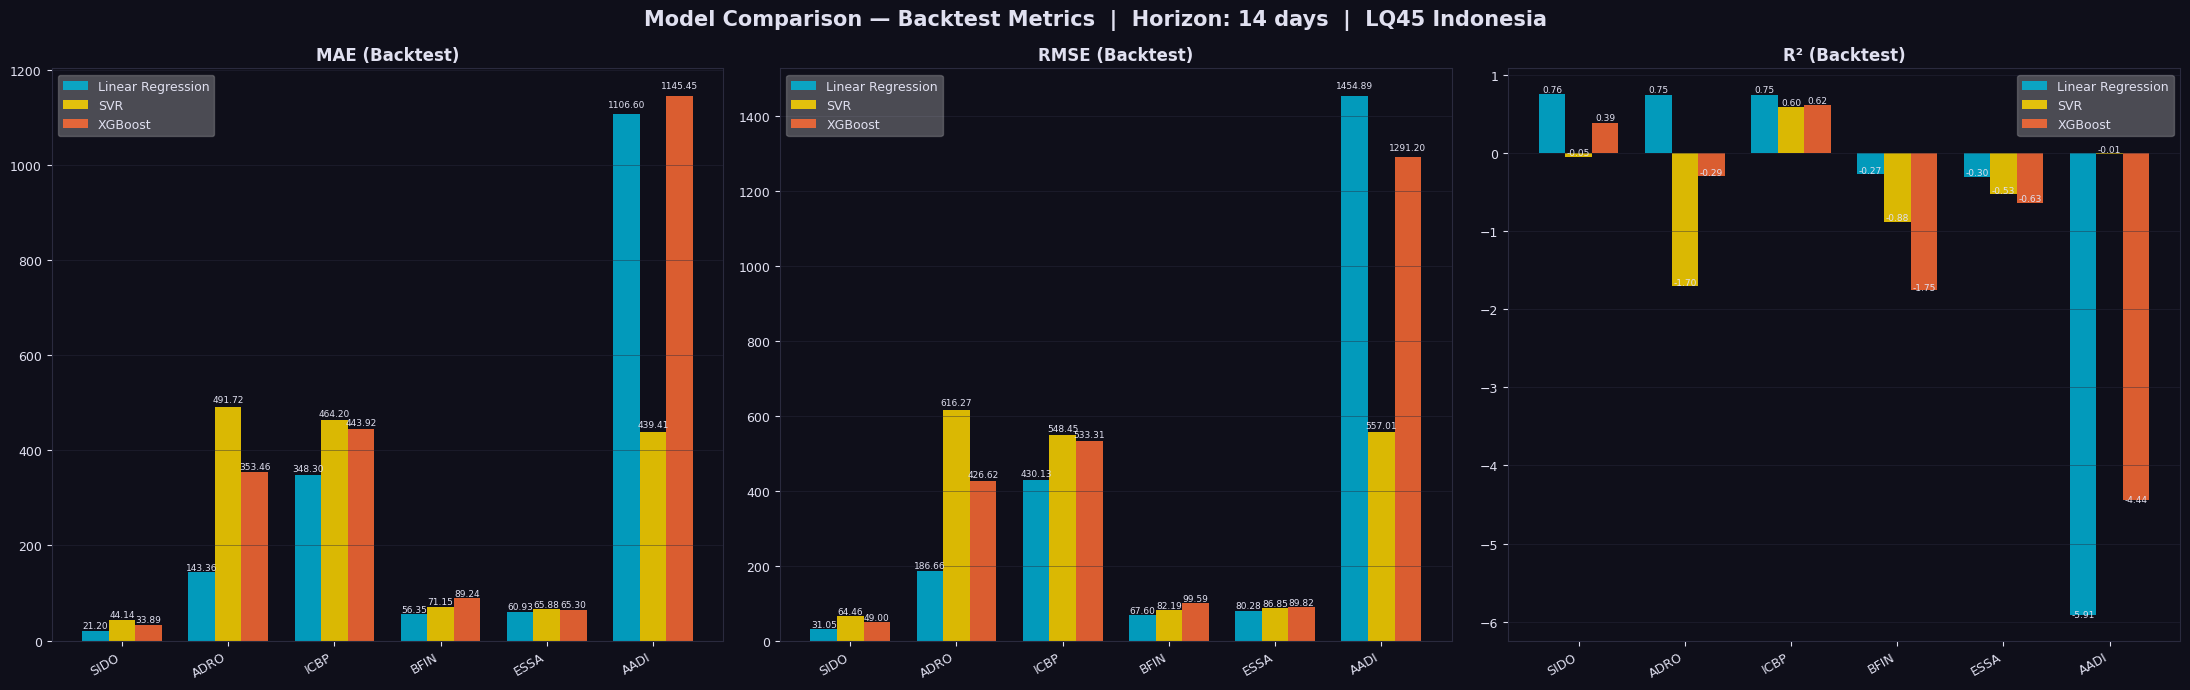

In [44]:
# Model Comparison — Linear Regression vs SVR vs XGBoost (display tickers)
def build_metrics_df(res):
    return pd.DataFrame({
        t: {
            'MAE_train':  res[t]['train_m']['MAE'],
            'RMSE_train': res[t]['train_m']['RMSE'],
            'R2_train':   res[t]['train_m']['R2'],
            'MAE_bt':     res[t]['bt_m']['MAE'],
            'RMSE_bt':    res[t]['bt_m']['RMSE'],
            'R2_bt':      res[t]['bt_m']['R2'],
        }
        for t in res
    }).T

mdf_lr  = build_metrics_df(results)
mdf_svr = build_metrics_df(results_svr)
mdf_xgb = build_metrics_df(results_xgb)

MODEL_NAMES  = ['Linear Regression', 'SVR', 'XGBoost']
MODEL_COLORS = ['#00b4d8', '#FFD700', '#FF6B35']

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.patch.set_facecolor(STYLE_BG)
fig.suptitle(f"Model Comparison — Backtest Metrics  |  Horizon: {HORIZON} days  |  LQ45 Indonesia",
             color=STYLE_TEXT, fontsize=15, fontweight='bold')

bw = 0.25
dx = np.arange(len(display_tickers))

for ax, (metric, title) in zip(axes, [('MAE_bt', 'MAE (Backtest)'),
                                       ('RMSE_bt', 'RMSE (Backtest)'),
                                       ('R2_bt',   'R² (Backtest)')]):
    ax.set_facecolor(STYLE_BG)
    ax.tick_params(colors=STYLE_TEXT, labelsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor(STYLE_GRID)
    ax.grid(color=STYLE_GRID, lw=0.5, axis='y', alpha=0.6)

    for i, (mdf, mname, mc) in enumerate(zip([mdf_lr, mdf_svr, mdf_xgb], MODEL_NAMES, MODEL_COLORS)):
        vals = [mdf.loc[t, metric] if t in mdf.index else np.nan for t in display_tickers]
        bars = ax.bar(dx + i * bw, vals, bw, label=mname, color=mc, alpha=0.85)
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width() / 2., h * 1.01,
                        f'{h:.2f}', ha='center', va='bottom', color=STYLE_TEXT, fontsize=6.5)

    ax.set_xticks(dx + bw)
    ax.set_xticklabels([t.replace('.JK', '') for t in display_tickers],
                       color=STYLE_TEXT, fontsize=9, rotation=30, ha='right')
    ax.set_title(title, color=STYLE_TEXT, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.25, labelcolor=STYLE_TEXT)

plt.tight_layout()
plt.show()

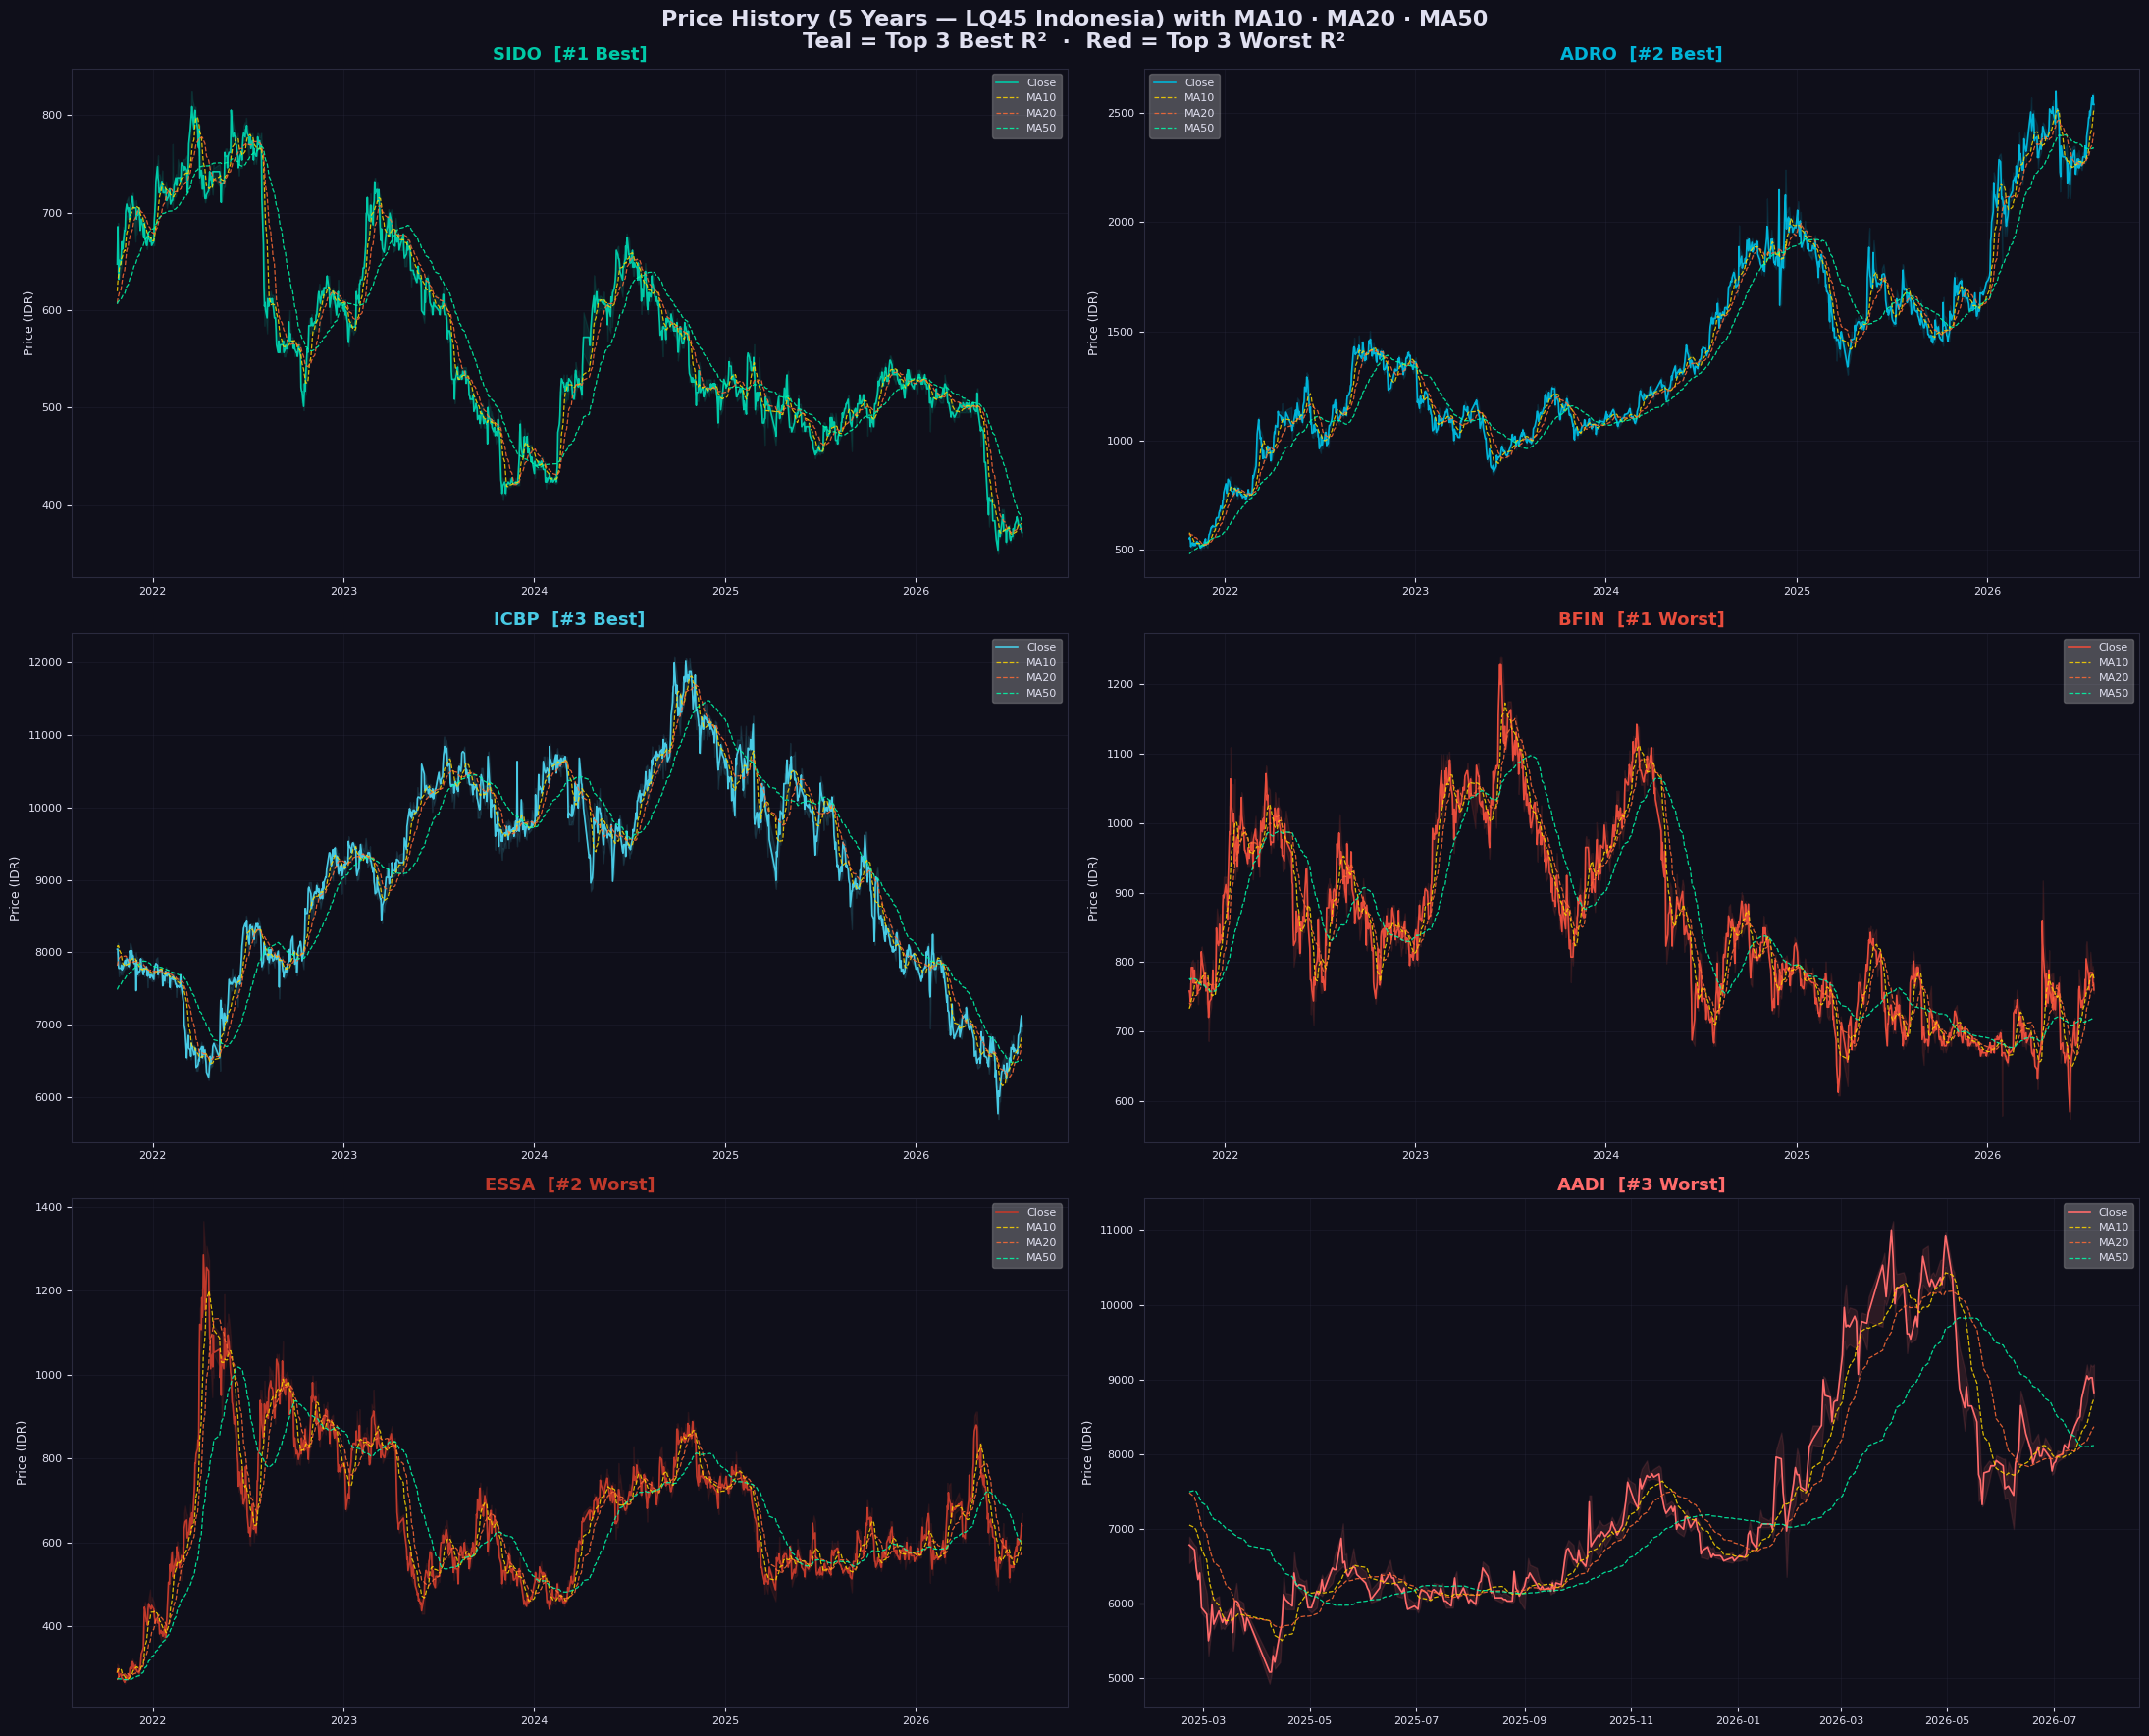

In [45]:
# Price History — Top 3 Best, Worst 3
fig, axes = plt.subplots(3, 2, figsize=(22, 18))
fig.patch.set_facecolor(STYLE_BG)
fig.suptitle("Price History (5 Years — LQ45 Indonesia) with MA10 \u00b7 MA20 \u00b7 MA50\n"
             "Teal = Top 3 Best R\u00b2  \u00b7  Red = Top 3 Worst R\u00b2",
             color=STYLE_TEXT, fontsize=16, fontweight='bold')

for ax, ticker in zip(axes.flat, display_tickers):
    grp = df_feat[df_feat['Ticker'] == ticker]
    c   = DISPLAY_COLORS[ticker]
    ax.set_facecolor(STYLE_BG)
    ax.tick_params(colors=STYLE_TEXT, labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(STYLE_GRID)
    ax.grid(color=STYLE_GRID, linewidth=0.4, alpha=0.6)

    ax.fill_between(grp['Date'], grp['Low'], grp['High'], alpha=0.12, color=c)
    ax.plot(grp['Date'], grp['Close'], color=c,         lw=1.2,  label='Close')
    ax.plot(grp['Date'], grp['MA10'],  color='#FFD700', lw=0.9,  ls='--', alpha=0.85, label='MA10')
    ax.plot(grp['Date'], grp['MA20'],  color='#FF6B35', lw=0.9,  ls='--', alpha=0.85, label='MA20')
    ax.plot(grp['Date'], grp['MA50'],  color='#00FFAA', lw=0.9,  ls='--', alpha=0.85, label='MA50')

    lbl = ticker.replace('.JK', '')
    ax.set_title(f"{lbl}  [{rank_label[ticker]}]", color=c, fontsize=13, fontweight='bold')
    ax.set_ylabel('Price (IDR)', color=STYLE_TEXT, fontsize=9)
    ax.legend(fontsize=8, framealpha=0.25, labelcolor=STYLE_TEXT)

plt.tight_layout()
plt.show()

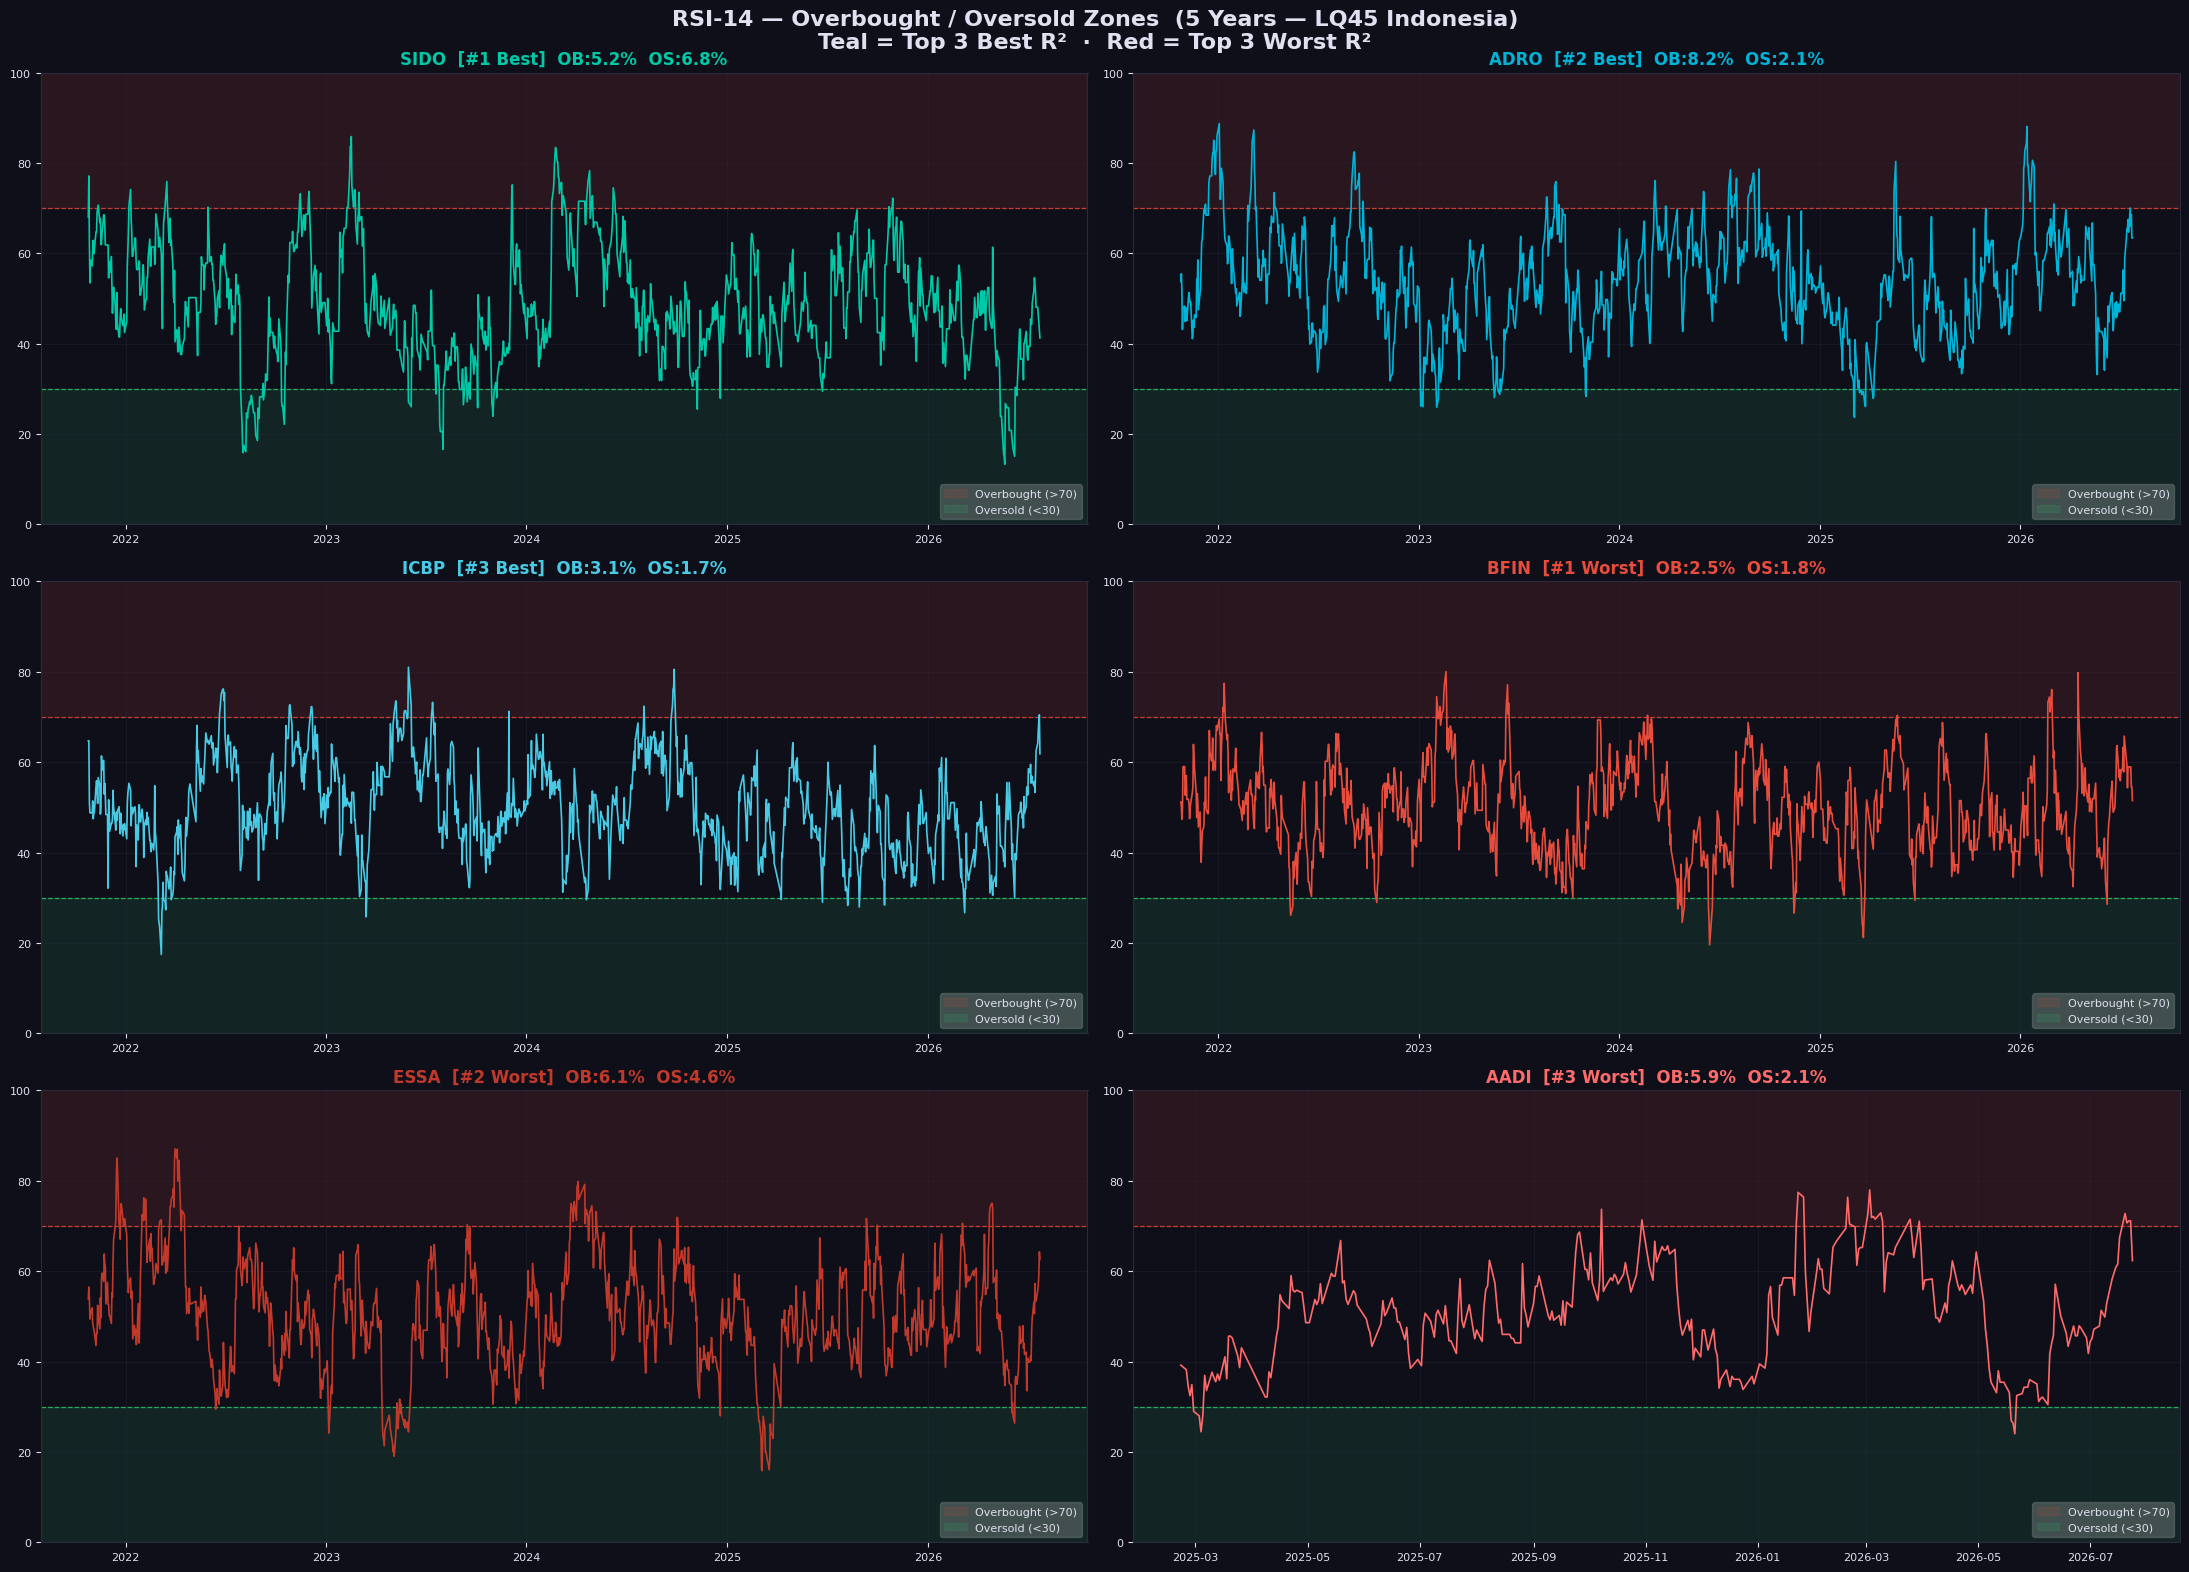

In [46]:
# RSI-14 — Top 3 Best, Worst 3
fig, axes = plt.subplots(3, 2, figsize=(22, 16))
fig.patch.set_facecolor(STYLE_BG)
fig.suptitle("RSI-14 \u2014 Overbought / Oversold Zones  (5 Years \u2014 LQ45 Indonesia)\n"
             "Teal = Top 3 Best R\u00b2  \u00b7  Red = Top 3 Worst R\u00b2",
             color=STYLE_TEXT, fontsize=16, fontweight='bold')

for ax, ticker in zip(axes.flat, display_tickers):
    grp = df_feat[df_feat['Ticker'] == ticker]
    c   = DISPLAY_COLORS[ticker]
    rsi = grp['RSI14']

    ax.set_facecolor(STYLE_BG)
    ax.tick_params(colors=STYLE_TEXT, labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(STYLE_GRID)
    ax.grid(color=STYLE_GRID, linewidth=0.4, alpha=0.6)

    ax.axhspan(70, 100, alpha=0.12, color='#e74c3c', label='Overbought (>70)')
    ax.axhspan(0,  30,  alpha=0.12, color='#2ecc71', label='Oversold (<30)')
    ax.axhline(70, color='#e74c3c', lw=0.9, ls='--', alpha=0.8)
    ax.axhline(30, color='#2ecc71', lw=0.9, ls='--', alpha=0.8)
    ax.plot(grp['Date'], rsi, color=c, lw=1.2)

    pct_ob = (rsi > 70).mean() * 100
    pct_os = (rsi < 30).mean() * 100
    lbl    = ticker.replace('.JK', '')
    ax.set_title(f"{lbl}  [{rank_label[ticker]}]  OB:{pct_ob:.1f}%  OS:{pct_os:.1f}%",
                 color=c, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8, framealpha=0.2, labelcolor=STYLE_TEXT, loc='lower right')

plt.tight_layout()
plt.show()

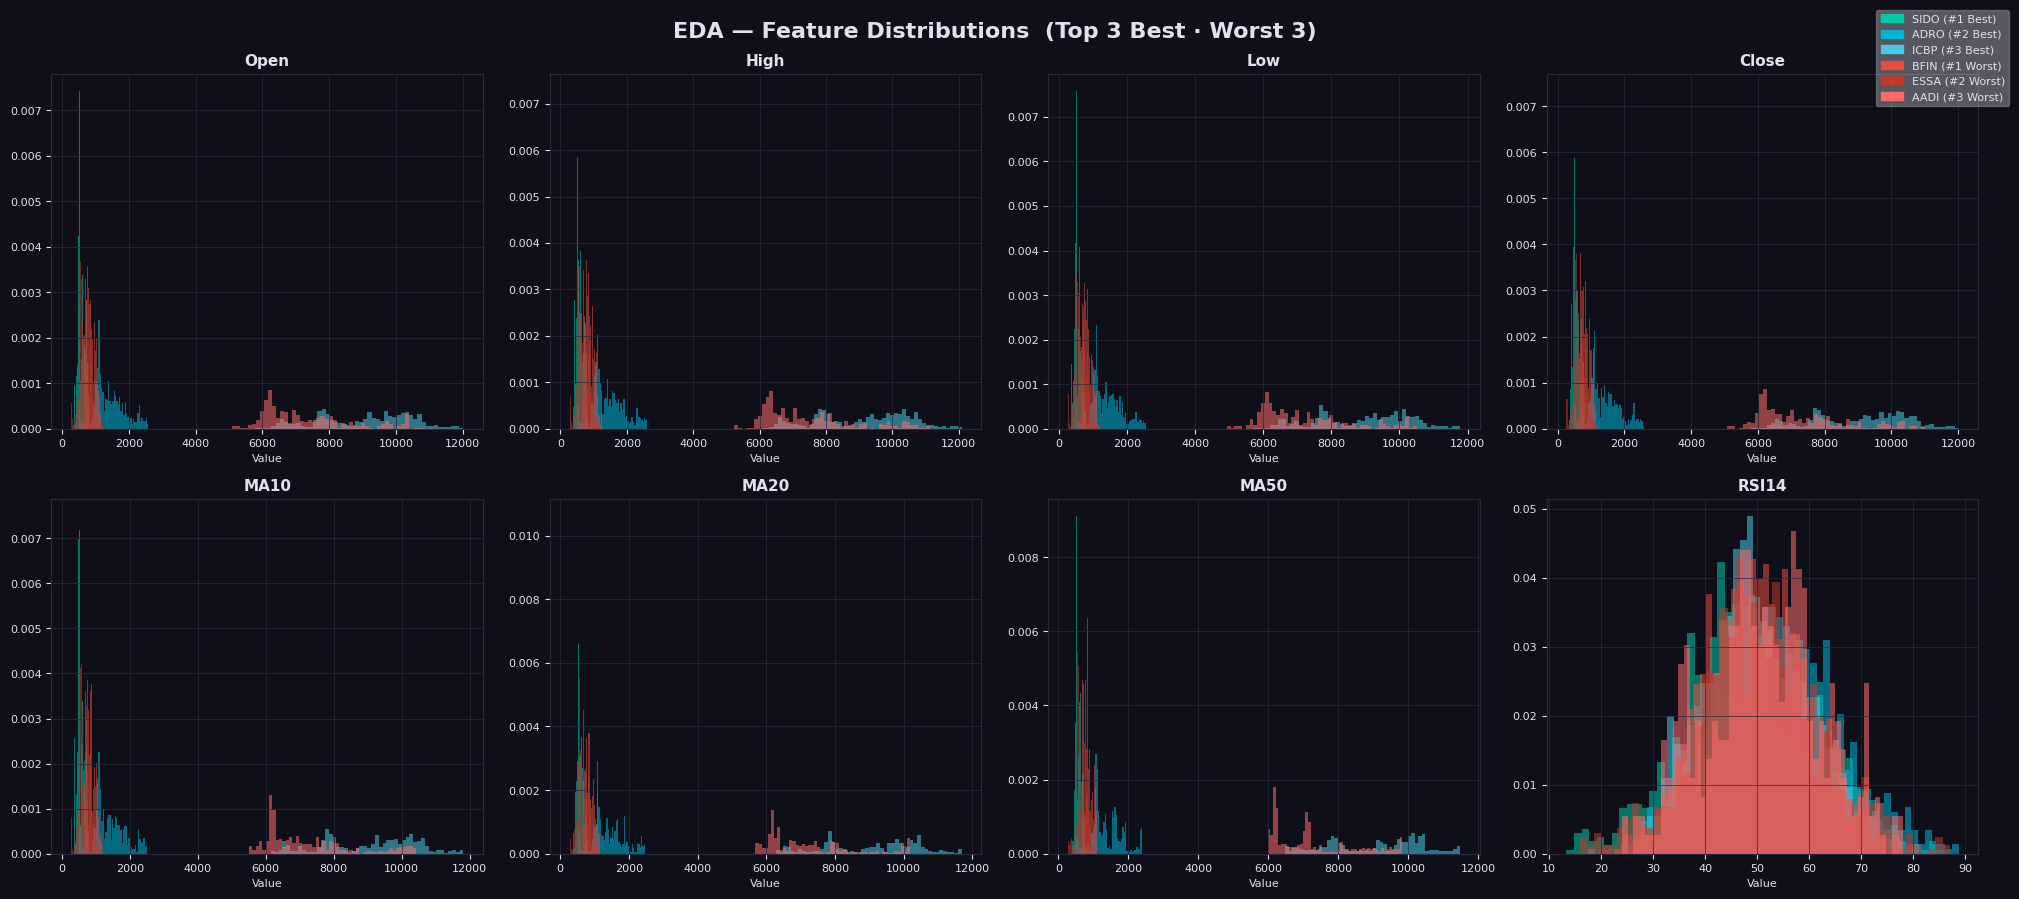

In [47]:
# Feature Distribution — (Top 3 Best, Worst 3)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.patch.set_facecolor(STYLE_BG)
fig.suptitle("EDA \u2014 Feature Distributions  (Top 3 Best \u00b7 Worst 3)",
             color=STYLE_TEXT, fontsize=16, fontweight='bold')

for ax, feat in zip(axes.flat, FEATURES):
    ax.set_facecolor(STYLE_BG)
    ax.tick_params(colors=STYLE_TEXT, labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(STYLE_GRID)
    ax.grid(color=STYLE_GRID, linewidth=0.5)
    for ticker in display_tickers:
        grp = df_feat[df_feat['Ticker'] == ticker]
        lbl = f"{ticker.replace('.JK','')} ({rank_label[ticker]})"
        ax.hist(grp[feat].dropna(), bins=50, alpha=0.55,
                color=DISPLAY_COLORS[ticker], label=lbl, density=True)
    ax.set_title(feat, color=STYLE_TEXT, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value', color=STYLE_TEXT, fontsize=8)

handles = [Patch(color=DISPLAY_COLORS[t],
                 label=t.replace('.JK','') + f' ({rank_label[t]})')
           for t in display_tickers]
fig.legend(handles=handles, loc='upper right', framealpha=0.3,
           labelcolor=STYLE_TEXT, fontsize=8, bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

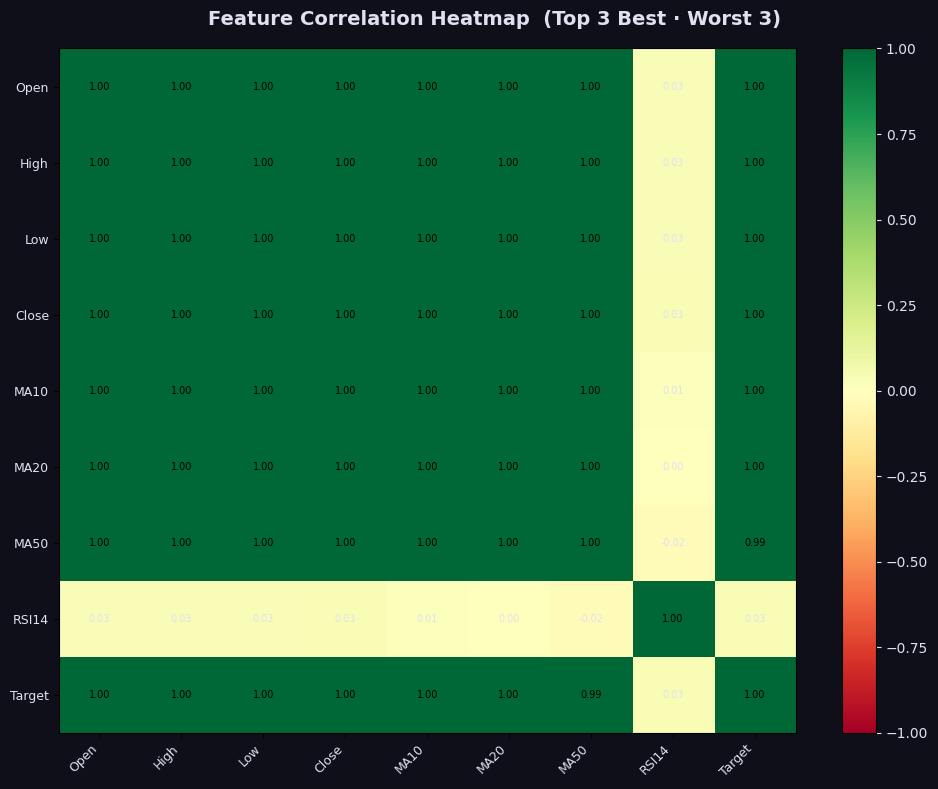

In [48]:
# Correlation Heatmap
sub    = df_feat[df_feat['Ticker'].isin(display_tickers)]
corr   = sub[FEATURES + ['Target']].corr()
labels = corr.columns.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(STYLE_BG)
ax.set_facecolor(STYLE_BG)
fig.suptitle("Feature Correlation Heatmap  (Top 3 Best \u00b7 Worst 3)",
             color=STYLE_TEXT, fontsize=14, fontweight='bold')

im   = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=STYLE_TEXT)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=STYLE_TEXT)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', color=STYLE_TEXT, fontsize=9)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, color=STYLE_TEXT, fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=7,
                color='black' if abs(v) > 0.6 else STYLE_TEXT)

plt.tight_layout()
plt.show()

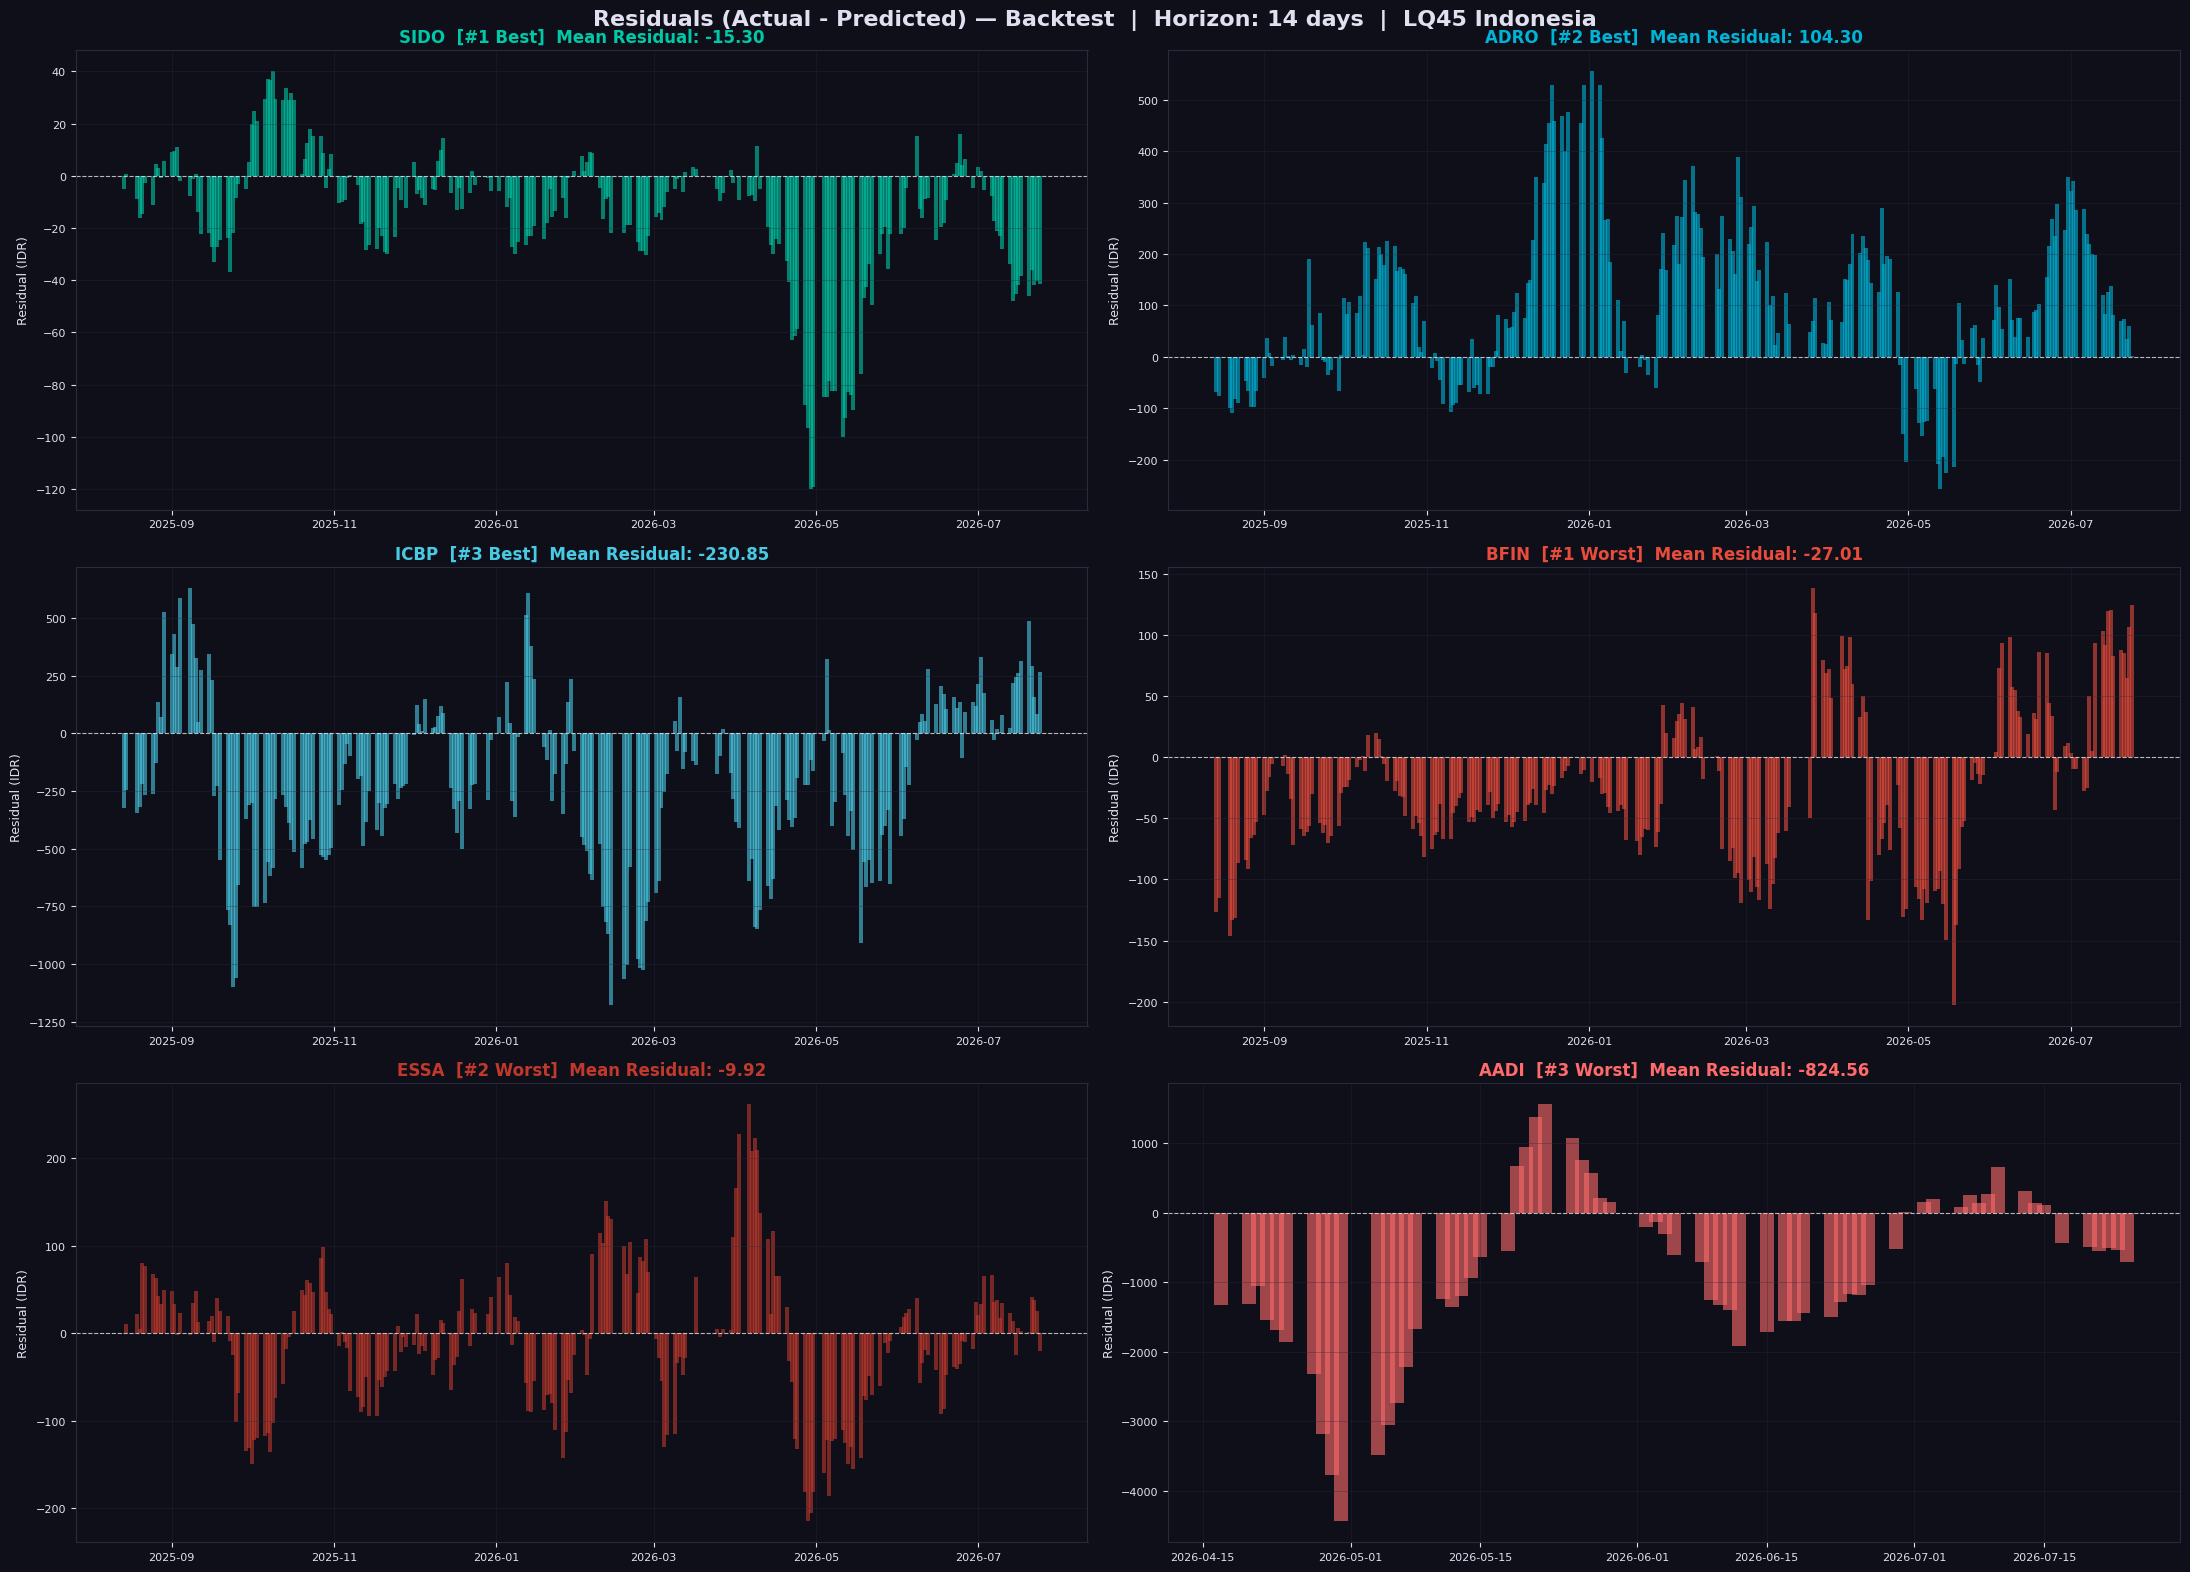

In [49]:
# Residuals — Backtest  (Top 3 Best, Worst 3)
fig, axes = plt.subplots(3, 2, figsize=(22, 16))
fig.patch.set_facecolor(STYLE_BG)
fig.suptitle(f"Residuals (Actual - Predicted) \u2014 Backtest  |  Horizon: {HORIZON} days  |  LQ45 Indonesia",
             color=STYLE_TEXT, fontsize=16, fontweight='bold')

for ax, ticker in zip(axes.flat, display_tickers):
    r         = results[ticker]
    si        = r['split']
    dates_bt  = r['grp']['Date'].values[si:]
    residuals = r['y_bt'] - r['y_pred_bt']
    c         = DISPLAY_COLORS[ticker]

    ax.set_facecolor(STYLE_BG)
    ax.tick_params(colors=STYLE_TEXT, labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(STYLE_GRID)
    ax.grid(color=STYLE_GRID, lw=0.4, alpha=0.6)

    ax.bar(dates_bt, residuals, color=c, alpha=0.6, width=1.5)
    ax.axhline(0, color='white', lw=0.8, ls='--', alpha=0.7)
    lbl = ticker.replace('.JK', '')
    ax.set_title(f"{lbl}  [{rank_label[ticker]}]  Mean Residual: {residuals.mean():.2f}",
                 color=c, fontsize=12, fontweight='bold')
    ax.set_ylabel('Residual (IDR)', color=STYLE_TEXT, fontsize=9)

plt.tight_layout()
plt.show()

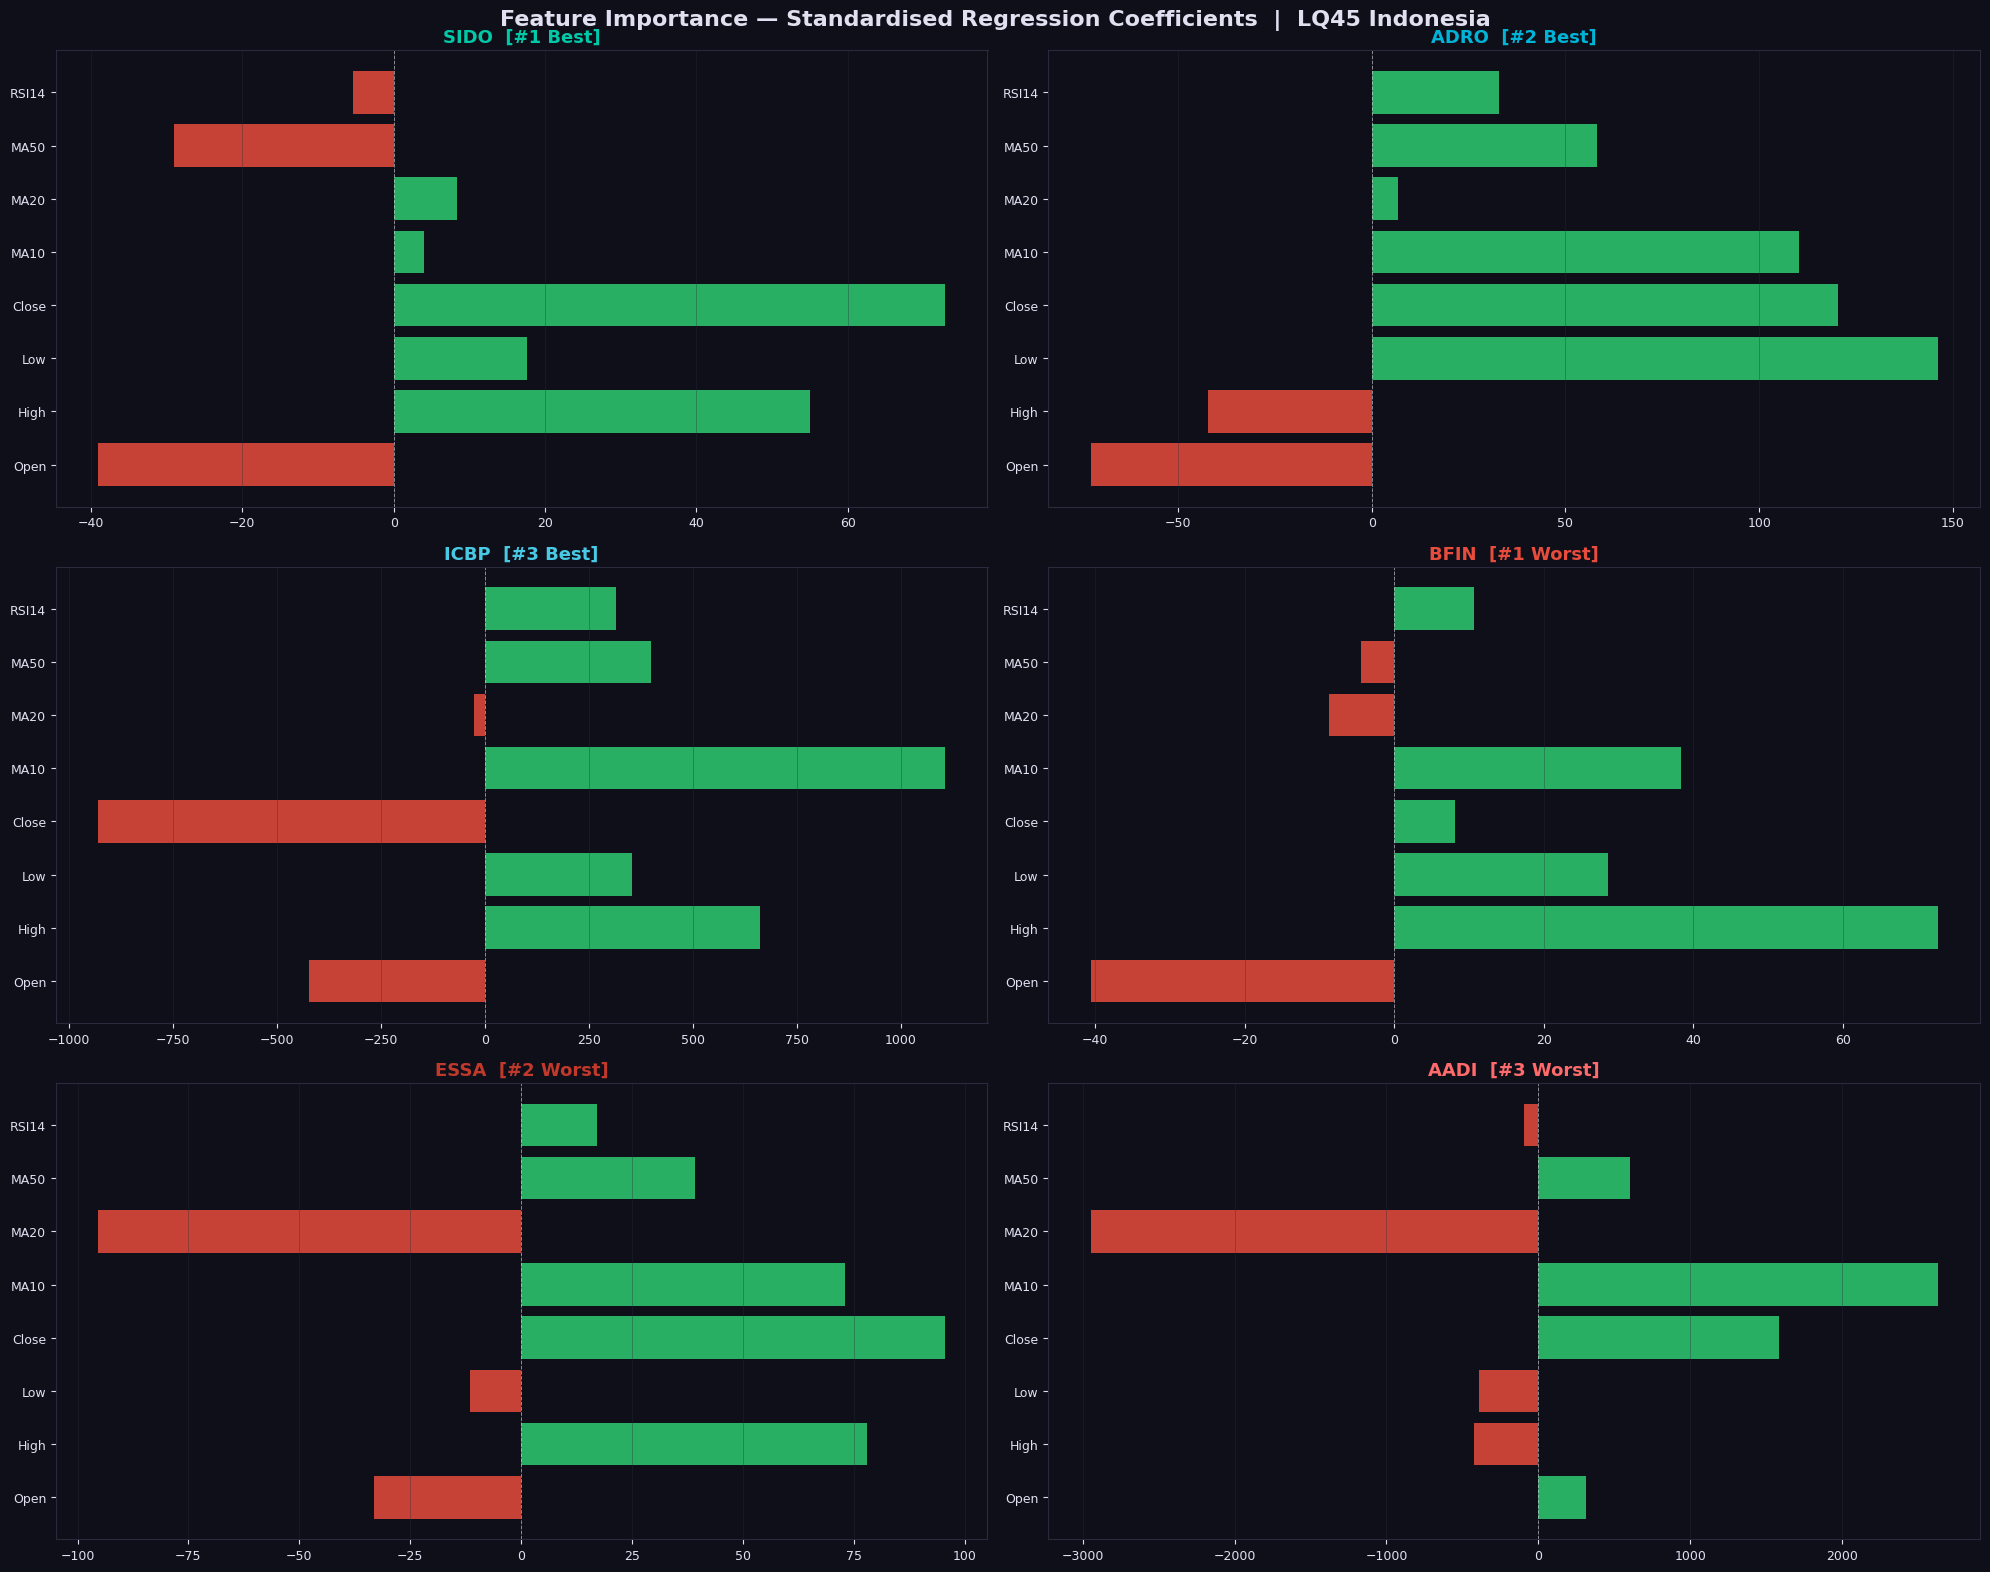

In [50]:
# Standardised Coefficients  (Top 3 Best, Worst 3)
fig, axes = plt.subplots(3, 2, figsize=(20, 16))
fig.patch.set_facecolor(STYLE_BG)
fig.suptitle("Feature Importance \u2014 Standardised Regression Coefficients  |  LQ45 Indonesia",
             color=STYLE_TEXT, fontsize=16, fontweight='bold')

for ax, ticker in zip(axes.flat, display_tickers):
    coef   = results[ticker]['coef']
    feats  = list(coef.keys())
    vals   = list(coef.values())
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in vals]

    ax.set_facecolor(STYLE_BG)
    ax.tick_params(colors=STYLE_TEXT, labelsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor(STYLE_GRID)
    ax.grid(color=STYLE_GRID, lw=0.4, axis='x', alpha=0.6)

    ax.barh(feats, vals, color=colors, alpha=0.85)
    ax.axvline(0, color='white', lw=0.7, ls='--', alpha=0.5)
    lbl = ticker.replace('.JK', '')
    ax.set_title(f"{lbl}  [{rank_label[ticker]}]",
                 color=DISPLAY_COLORS[ticker], fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

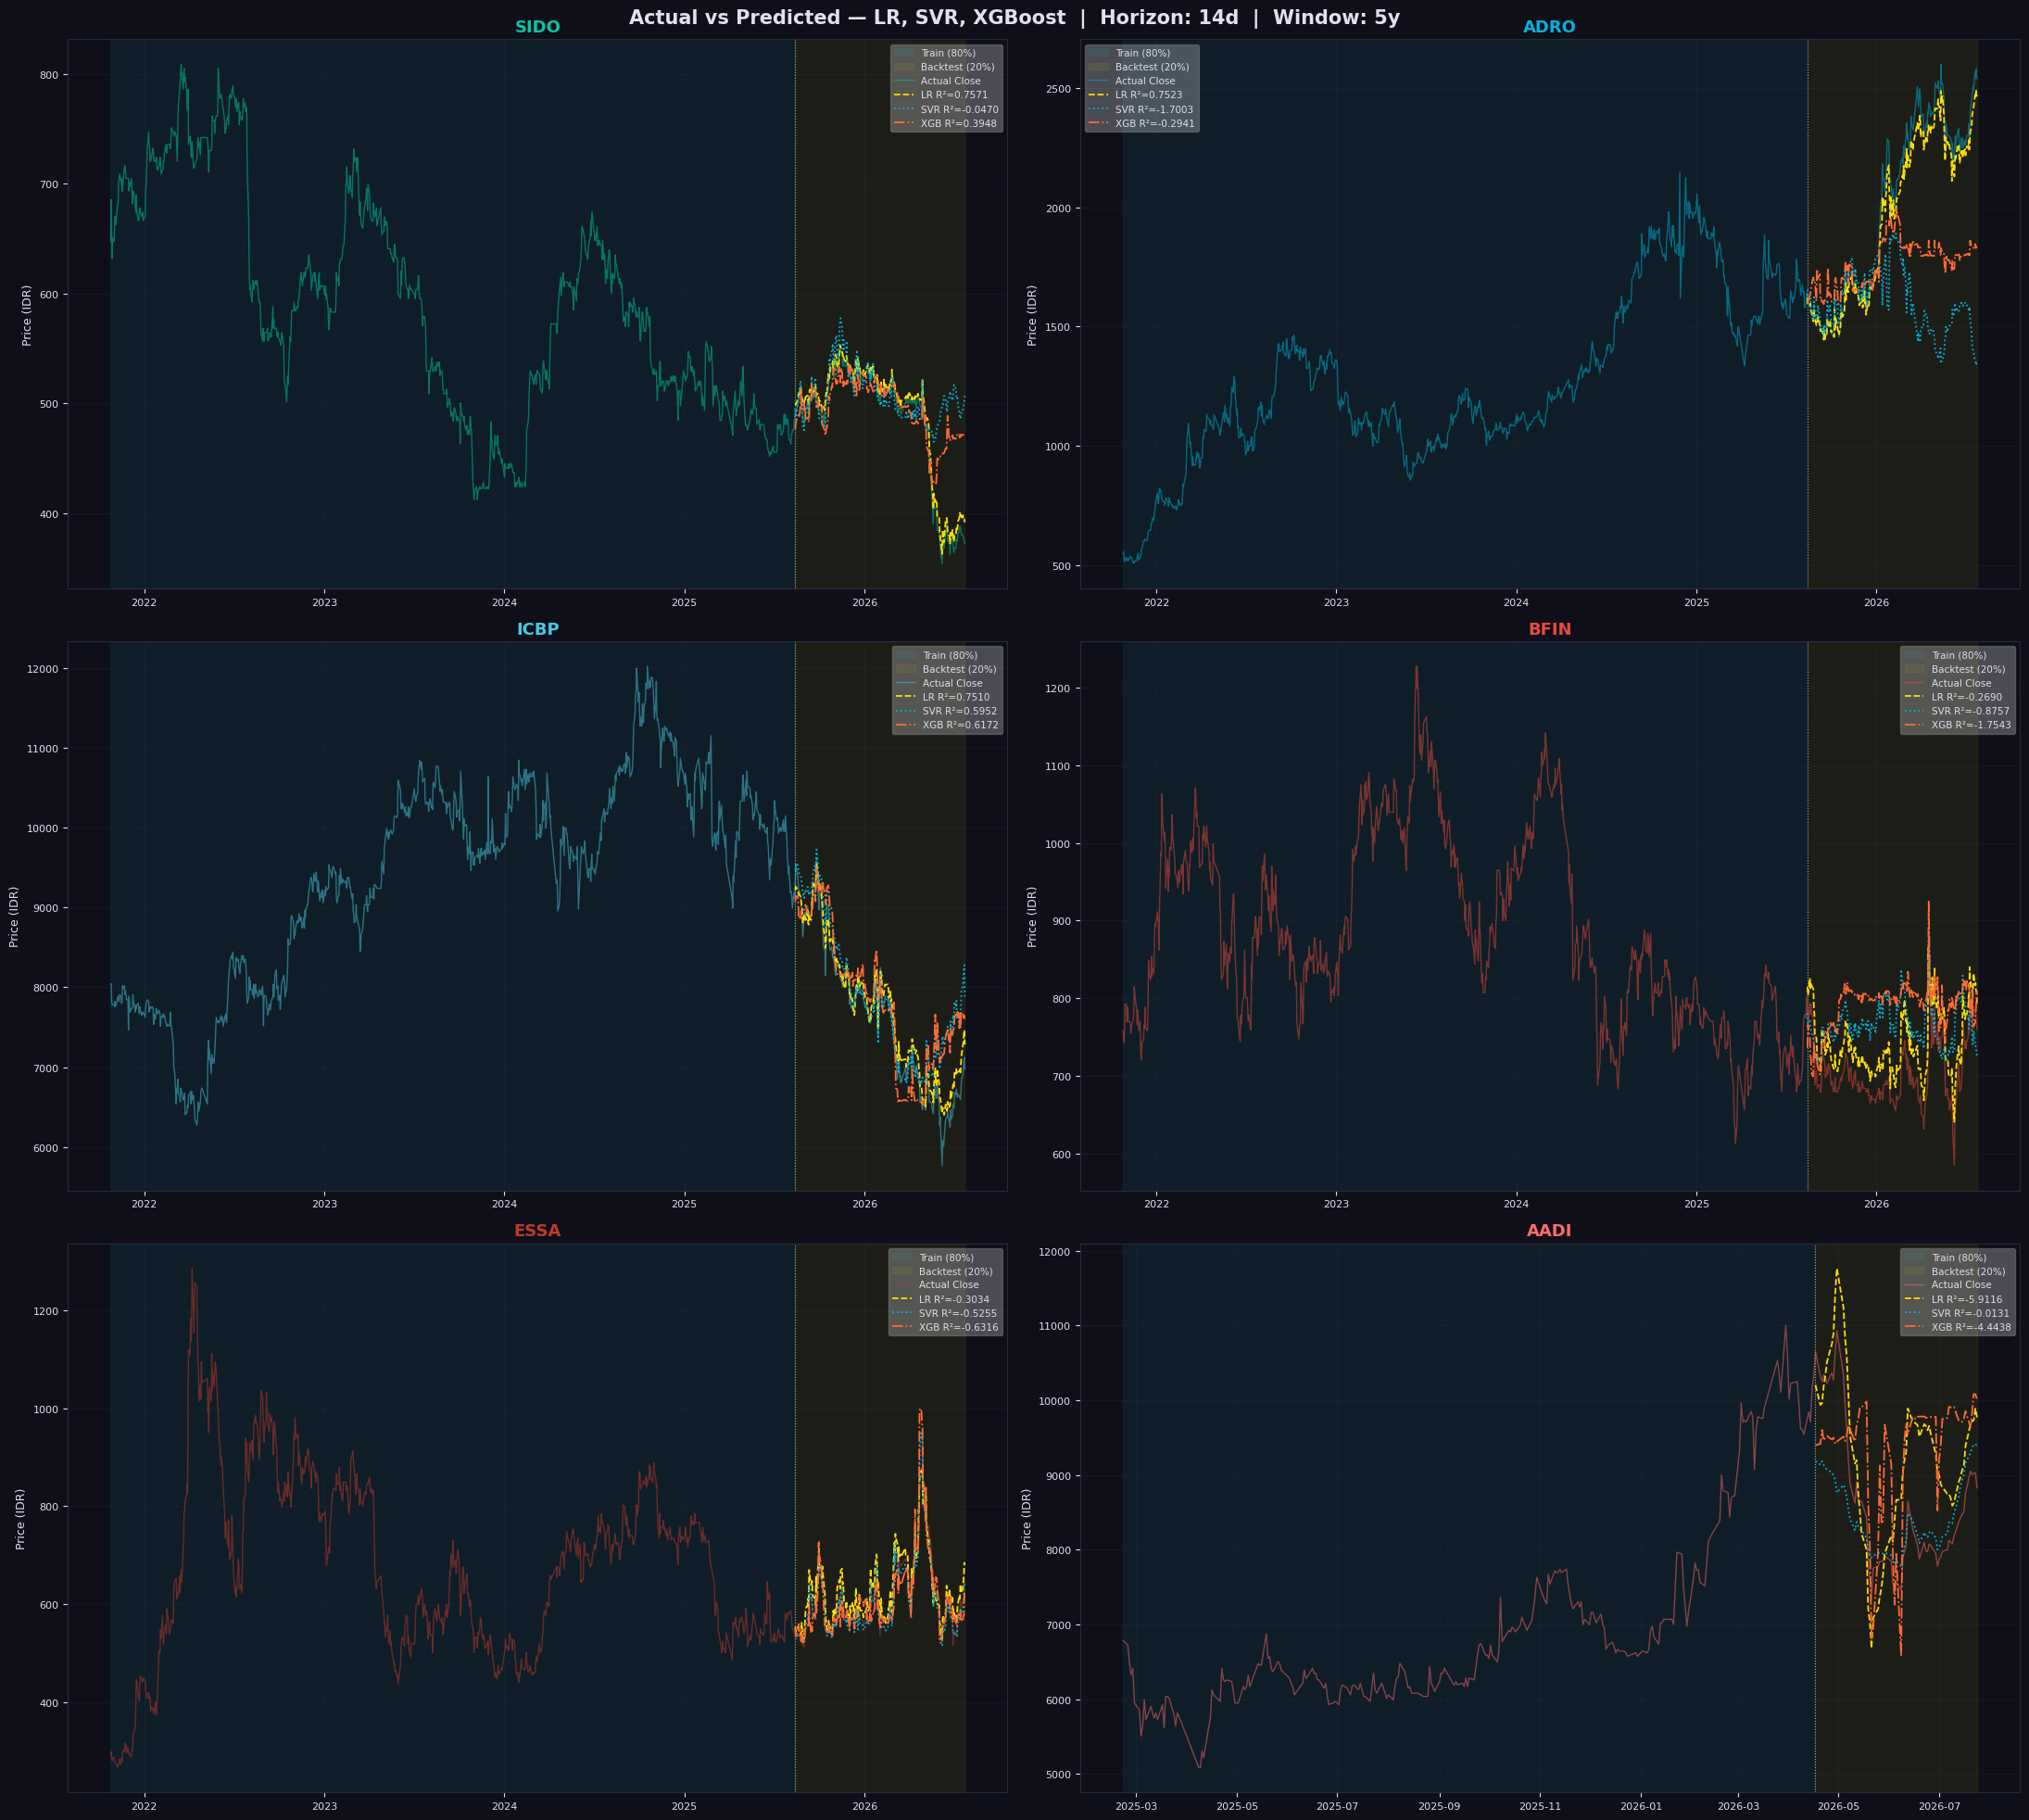

In [51]:
#  Actual vs Predicted — Backtest (Linear Regression, SVR, XGBoost)
fig, axes = plt.subplots(3, 2, figsize=(22, 20))
fig.patch.set_facecolor(STYLE_BG)
fig.suptitle(
    f'Actual vs Predicted — LR, SVR, XGBoost  |  Horizon: {HORIZON}d  |  Window: {PERIOD}',
    color=STYLE_TEXT, fontsize=15, fontweight='bold')

for ax, ticker in zip(axes.flat, display_tickers):
    c           = DISPLAY_COLORS[ticker]
    grp         = results[ticker]['grp']
    si          = results[ticker]['split']
    dates_all   = grp['Date'].values
    close_all   = grp['Close'].values
    dates_bt    = dates_all[si:]

    # Linear Regression results
    y_pred_bt_lr = results[ticker]['y_pred_bt']
    bt_r2_lr     = results[ticker]['bt_m']['R2']

    # SVR results
    y_pred_bt_svr = results_svr[ticker]['y_pred_bt']
    bt_r2_svr     = results_svr[ticker]['bt_m']['R2']

    # XGBoost results
    y_pred_bt_xgb = results_xgb[ticker]['y_pred_bt']
    bt_r2_xgb     = results_xgb[ticker]['bt_m']['R2']

    ax.set_facecolor(STYLE_BG)
    ax.tick_params(colors=STYLE_TEXT, labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(STYLE_GRID)
    ax.grid(color=STYLE_GRID, lw=0.4, alpha=0.6)

    ax.axvspan(dates_all[0],  dates_all[si-1], alpha=0.06, color='cyan',   label='Train (80%)')
    ax.axvspan(dates_all[si], dates_all[-1],   alpha=0.06, color='yellow', label='Backtest (20%)')
    ax.axvline(x=dates_all[si], color='white', lw=0.8, ls=':', alpha=0.6)
    ax.plot(dates_all, close_all, color=c, lw=1.0, alpha=0.5, label='Actual Close')
    ax.plot(dates_bt, y_pred_bt_lr, color='#FFDD00', lw=1.3, ls='--', label=f'LR R²={bt_r2_lr:.4f}')
    ax.plot(dates_bt, y_pred_bt_svr, color='#00b4d8', lw=1.3, ls=':', label=f'SVR R²={bt_r2_svr:.4f}')
    ax.plot(dates_bt, y_pred_bt_xgb, color='#FF6B35', lw=1.3, ls='-.', label=f'XGB R²={bt_r2_xgb:.4f}')

    lbl = ticker.replace('.JK', '')
    ax.set_title(f"{lbl}", color=c, fontsize=13, fontweight='bold')
    ax.set_ylabel('Price (IDR)', color=STYLE_TEXT, fontsize=9)
    ax.legend(fontsize=7.5, framealpha=0.25, labelcolor=STYLE_TEXT)

plt.tight_layout()
plt.show()

In [52]:
import numpy as np, pandas as pd
from itertools import product
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

tscv    = TimeSeriesSplit(n_splits=5)
tickers = df_feat['Ticker'].unique().tolist()

def _split(ticker):
    grp = df_feat[df_feat['Ticker'] == ticker].reset_index(drop=True)
    X, y = grp[FEATURES].values, grp['Target'].values
    s = int(len(X) * 0.80)
    return X[:s], X[s:], y[:s], y[s:]

def _m(yt, yp):
    return {'MAE': mean_absolute_error(yt, yp),
            'RMSE': np.sqrt(mean_squared_error(yt, yp)),
            'R2': r2_score(yt, yp)}

def global_search(estimator, grid):
    """Pick the ONE config with best mean CV-R2 averaged across all 45 tickers."""
    keys, best = list(grid), None
    for combo in product(*grid.values()):
        params = dict(zip(keys, combo))
        scores = []
        for t in tickers:
            X_tr, _, y_tr, _ = _split(t)
            pipe = Pipeline([('scaler', StandardScaler()),
                             ('model', estimator.set_params(**params))])
            cv = cross_val_score(pipe, X_tr, y_tr, cv=tscv, scoring='r2', n_jobs=-1)
            scores.append(cv.mean())
        mean_r2 = np.mean(scores)
        print(f"  {params} -> mean CV-R2 {mean_r2:.4f}")
        if best is None or mean_r2 > best[1]:
            best = (params, mean_r2)
    return best[0]

svr_grid = {'C': [1, 10, 100, 1000], 'gamma': ['scale', 0.01, 0.1], 'epsilon': [0.01, 0.1, 0.5]}
xgb_grid = {'n_estimators': [200, 500], 'max_depth': [3, 5],
            'learning_rate': [0.03, 0.1]}

print("Global SVR search ...")
svr_best = global_search(SVR(kernel='rbf'), svr_grid)
print("\nGlobal XGB search ...")
xgb_best = global_search(XGBRegressor(random_state=42, verbosity=0), xgb_grid)

print(f"\nCHOSEN SVR : {svr_best}")
print(f"CHOSEN XGB : {xgb_best}")

Global SVR search ...
  {'C': 1, 'gamma': 'scale', 'epsilon': 0.01} -> mean CV-R2 -9.0371
  {'C': 1, 'gamma': 'scale', 'epsilon': 0.1} -> mean CV-R2 -9.0375
  {'C': 1, 'gamma': 'scale', 'epsilon': 0.5} -> mean CV-R2 -9.0415
  {'C': 1, 'gamma': 0.01, 'epsilon': 0.01} -> mean CV-R2 -9.1198
  {'C': 1, 'gamma': 0.01, 'epsilon': 0.1} -> mean CV-R2 -9.1203
  {'C': 1, 'gamma': 0.01, 'epsilon': 0.5} -> mean CV-R2 -9.1162
  {'C': 1, 'gamma': 0.1, 'epsilon': 0.01} -> mean CV-R2 -8.8238
  {'C': 1, 'gamma': 0.1, 'epsilon': 0.1} -> mean CV-R2 -8.8244
  {'C': 1, 'gamma': 0.1, 'epsilon': 0.5} -> mean CV-R2 -8.8261
  {'C': 10, 'gamma': 'scale', 'epsilon': 0.01} -> mean CV-R2 -5.2710
  {'C': 10, 'gamma': 'scale', 'epsilon': 0.1} -> mean CV-R2 -5.2714
  {'C': 10, 'gamma': 'scale', 'epsilon': 0.5} -> mean CV-R2 -5.2661
  {'C': 10, 'gamma': 0.01, 'epsilon': 0.01} -> mean CV-R2 -3.5006
  {'C': 10, 'gamma': 0.01, 'epsilon': 0.1} -> mean CV-R2 -3.5006
  {'C': 10, 'gamma': 0.01, 'epsilon': 0.5} -> mean CV-R2 

In [53]:
# Tuned SVR Model
tuned_svr = {}
for t in tickers:
    X_tr, X_bt, y_tr, y_bt = _split(t)
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', SVR(kernel='rbf').set_params(**svr_best))])
    pipe.fit(X_tr, y_tr)
    tuned_svr[t] = {'train_m': _m(y_tr, pipe.predict(X_tr)),
                    'bt_m':    _m(y_bt, pipe.predict(X_bt))}

svr_mdf = (pd.DataFrame({t: {'R2_BT': tuned_svr[t]['bt_m']['R2']} for t in tuned_svr})
           .T.sort_values('R2_BT', ascending=False))

print(f"Tuned SVR  |  config: {svr_best}  |  Horizon: {HORIZON}d")
print(f"{'Ticker':<10}{'R2 Train':>10}{'R2 BT':>9}{'MAE BT':>11}{'RMSE BT':>11}")
print('-'*56)
for t in svr_mdf.index:
    r = tuned_svr[t]
    print(f"{t.replace('.JK',''):<10}{r['train_m']['R2']:>10.4f}"
          f"{r['bt_m']['R2']:>9.4f}{r['bt_m']['MAE']:>11.2f}{r['bt_m']['RMSE']:>11.2f}")

r2 = [tuned_svr[t]['bt_m']['R2'] for t in tuned_svr]
print('-'*56)
print(f"positive R2: {sum(x>0 for x in r2)}/{len(r2)}  |  mean {np.mean(r2):.4f}  |  median {np.median(r2):.4f}")

Tuned SVR  |  config: {'C': 100, 'gamma': 0.01, 'epsilon': 0.5}  |  Horizon: 14d
Ticker      R2 Train    R2 BT     MAE BT    RMSE BT
--------------------------------------------------------
ICBP          0.8863   0.6870     402.93     482.24
INTP          0.9032   0.6847     355.10     431.81
GOTO          0.9256   0.6651       2.72       3.79
BUKA          0.9156   0.6443      10.95      14.17
BBCA          0.9004   0.6311     376.04     470.80
BJTM          0.7538   0.5470      11.14      14.90
SIDO          0.8536   0.5341      30.96      43.00
MAPI          0.8969   0.5120      82.10     106.53
TLKM          0.8541   0.4946     168.22     207.90
SMGR          0.9429   0.4865     307.19     362.99
HRUM          0.8398   0.4686      88.57     109.96
MIKA          0.6961   0.4306     183.89     241.80
UNVR          0.9327   0.4229     178.14     243.32
BBRI          0.8383   0.4174     169.90     215.93
AMRT          0.9151   0.4014     162.20     207.34
INKP          0.7348   0.3867 

In [54]:
#Tuned XGB Model
tuned_xgb = {}
for t in tickers:
    X_tr, X_bt, y_tr, y_bt = _split(t)
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', XGBRegressor(random_state=42, verbosity=0).set_params(**xgb_best))])
    pipe.fit(X_tr, y_tr)
    tuned_xgb[t] = {'train_m': _m(y_tr, pipe.predict(X_tr)),
                    'bt_m':    _m(y_bt, pipe.predict(X_bt))}

xgb_mdf = (pd.DataFrame({t: {'R2_BT': tuned_xgb[t]['bt_m']['R2']} for t in tuned_xgb})
           .T.sort_values('R2_BT', ascending=False))

print(f"Tuned XGBoost  |  config: {xgb_best}  |  Horizon: {HORIZON}d")
print(f"{'Ticker':<10}{'R2 Train':>10}{'R2 BT':>9}{'MAE BT':>11}{'RMSE BT':>11}")
print('-'*56)
for t in xgb_mdf.index:
    r = tuned_xgb[t]
    print(f"{t.replace('.JK',''):<10}{r['train_m']['R2']:>10.4f}"
          f"{r['bt_m']['R2']:>9.4f}{r['bt_m']['MAE']:>11.2f}{r['bt_m']['RMSE']:>11.2f}")

r2 = [tuned_xgb[t]['bt_m']['R2'] for t in tuned_xgb]
print('-'*56)
print(f"positive R2: {sum(x>0 for x in r2)}/{len(r2)}  |  mean {np.mean(r2):.4f}  |  median {np.median(r2):.4f}")

Tuned XGBoost  |  config: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03}  |  Horizon: 14d
Ticker      R2 Train    R2 BT     MAE BT    RMSE BT
--------------------------------------------------------
ICBP          0.9618   0.6643     412.57     499.45
INTP          0.9761   0.6443     358.20     458.60
GOTO          0.9891   0.5367       3.82       4.45
MAPI          0.9542   0.5041      88.49     107.39
SIDO          0.9596   0.4818      31.73      45.35
TLKM          0.9432   0.4565     175.20     215.59
INKP          0.9060   0.4306     636.15     823.49
BUKA          0.9884   0.4095      14.68      18.26
BJTM          0.9164   0.3938      13.63      17.23
BBRI          0.9360   0.3587     179.43     226.56
BBCA          0.9666   0.3295     530.19     634.74
MDKA          0.9648   0.2836     273.19     365.34
HRUM          0.9584   0.2287     103.12     132.47
INCO          0.9698   0.2252     648.93     879.81
AKRA          0.9630   0.2198      79.01      97.40
MBMA   